# Regress trace element concentrations vs growth and environment

Author: **Niels J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

In [59]:
# Load necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import linregress, gaussian_kde
from scipy.odr import ODR, Model, RealData
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

## Example: One specimen

In [2]:
# Load one file from the folder
file_path = "TE_data_with_GR_T_S/G652_sub_peakid.csv"  # Test for one specimen
data = pd.read_csv(file_path)
data.head()

,depth,proxy_filtered,time,Xpos,Ypos,Ca43,23Na/43Ca,25Mg/43Ca,55Mn/43Ca,88Sr/43Ca,...,interval_growth_rate,interval_growth_rate_centered,interval_total_growth,interval_total_growth_centered,interval_total_time_days,T,T_std,S,S_std,Chl
0,0.426825,0.131868,62.87978,71074.74930,46513.67210,1650.108907,831.612523,6.181713,2.065418,0.131868,...,19.748683,31.612582,914.713074,1464.221264,46.317674,5.843,0.008,25.485,0.03,2.087
1,0.853650,0.108273,62.98893,71074.59489,46513.27419,1850.136910,694.830082,8.459364,1.591473,0.108273,...,19.748683,31.612582,914.713074,1464.221264,46.317674,5.843,0.008,25.485,0.03,2.087
2,1.280475,0.000000,63.09807,71074.44047,46512.87627,1500.090005,1055.629092,12.315843,2.279010,0.000000,...,19.748683,31.612582,914.713074,1464.221264,46.317674,5.843,0.008,25.485,0.03,2.087
3,1.707300,0.139467,63.20722,71074.28606,46512.47836,1600.102407,936.795248,32.690322,2.117207,0.139467,...,19.748683,31.612582,914.713074,1464.221264,46.317674,5.843,0.008,25.485,0.03,2.087
4,2.134126,0.065934,63.31641,71074.13164,46512.08044,1650.108907,889.753685,18.545361,2.128978,0.065934,...,19.748683,31.612582,914.713074,1464.221264,46.317674,5.872,0.025,25.39,0.073,2.087


### Plot Sr/Ca vs temperature

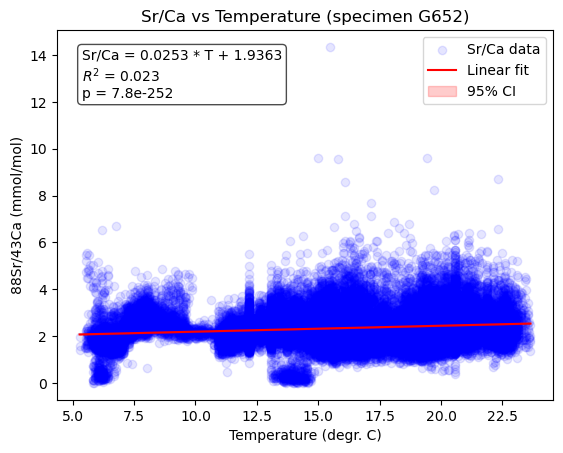

In [3]:
# Convert 'T' and 'T_std' columns to numeric, coerce errors to NaN
data['T'] = pd.to_numeric(data['T'], errors='coerce')
data['T_std'] = pd.to_numeric(data['T_std'], errors='coerce')

# Regression of Sr/Ca vs Temperature
# Remove rows with NaN in relevant columns
mask_temp = data[['T', '88Sr/43Ca']].notnull().all(axis=1)
x_temp = data.loc[mask_temp, 'T']
y_temp = data.loc[mask_temp, '88Sr/43Ca']

# Linear regression
slope_temp, intercept_temp, r_value_temp, p_value_temp, std_err_temp = linregress(x_temp, y_temp)
x_fit_temp = np.linspace(x_temp.min(), x_temp.max(), 200)
y_fit_temp = intercept_temp + slope_temp * x_fit_temp

# Calculate uncertainty envelope (95% confidence interval)
y_pred_temp = intercept_temp + slope_temp * x_temp
n_temp = len(x_temp)
t_val_temp = 1.96  # Approximate for large n, 95% CI
s_err_temp = np.sqrt(np.sum((y_temp - y_pred_temp) ** 2) / (n_temp - 2))
conf_temp = t_val_temp * s_err_temp * np.sqrt(1/n_temp + (x_fit_temp - np.mean(x_temp))**2 / np.sum((x_temp - np.mean(x_temp))**2))

# Plot Sr/Ca vs Temperature with uncertainties and regression fit in the same plot
plt.scatter(x_temp, y_temp, color='blue', alpha=0.1, label='Sr/Ca data')
plt.plot(x_fit_temp, y_fit_temp, color='red', label='Linear fit')
plt.fill_between(x_fit_temp, y_fit_temp - conf_temp, y_fit_temp + conf_temp, color='red', alpha=0.2, label='95% CI')
plt.xlabel('Temperature (degr. C)')
plt.ylabel('88Sr/43Ca (mmol/mol)')
plt.title('Sr/Ca vs Temperature (specimen G652)')

# Add regression statistics to the plot
eqn = f'Sr/Ca = {slope_temp:.4f} * T + {intercept_temp:.4f}'
stats = f'$R^2$ = {r_value_temp**2:.3f}\np = {p_value_temp:.1e}'
plt.text(0.05, 0.95, eqn + '\n' + stats, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.legend()
plt.show()

### Plot Sr/Ca vs growth rate

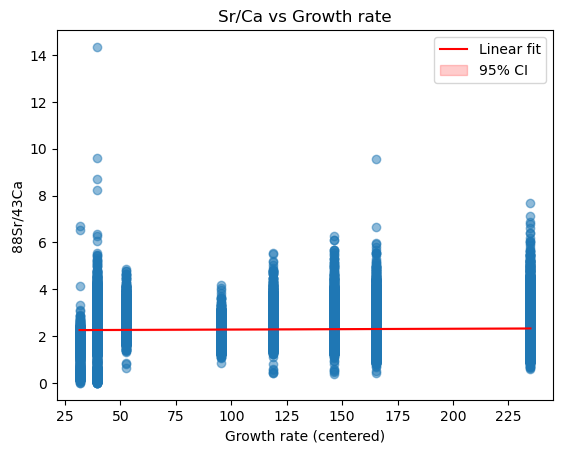

In [4]:
# Remove rows with NaN in relevant columns
mask = data[['interval_growth_rate_centered', '88Sr/43Ca']].notnull().all(axis=1)
x = data.loc[mask, 'interval_growth_rate_centered']
y = data.loc[mask, '88Sr/43Ca']

# Scatter plot
plt.plot(x, y, 'o', alpha=0.5)

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = intercept + slope * x_fit

# Calculate uncertainty envelope (95% confidence interval)
y_pred = intercept + slope * x
n = len(x)
t_val = 1.96  # Approximate for large n, 95% CI
s_err = np.sqrt(np.sum((y - y_pred) ** 2) / (n - 2))
conf = t_val * s_err * np.sqrt(1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))

plt.plot(x_fit, y_fit, color='red', label='Linear fit')
plt.fill_between(x_fit, y_fit - conf, y_fit + conf, color='red', alpha=0.2, label='95% CI')

plt.xlabel('Growth rate (centered)')
plt.ylabel('88Sr/43Ca')
plt.title('Sr/Ca vs Growth rate')
plt.legend()
plt.show()

## Combine data from all specimens

### Read data from all specimens

In [5]:
# Load all files from the folder
folder_path = "TE_data_with_GR_T_S/"
all_data = pd.DataFrame()
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        # Read each file
        file_data = pd.read_csv(
            os.path.join(folder_path, file),
            dtype={'T': "O", 'T_std': "O", 'S' : "O", 'S_std': "O"},
            index_col=0
        )
        # Add a column for the specimen name
        file_data['specimen'] = file.split('_')[0]  # Specimen name is the first part of the filename
        # Add column separating subtidal vs intertidal treatments
        file_data['treatment'] = 'intertidal' if file.split('_')[1] == 'int' else 'subtidal' if file.split('_')[1] == 'sub' else 'unknown'
        # Concatenate into a single DataFrame
        all_data = pd.concat([all_data, file_data], ignore_index=True)

# Display the first few rows of the combined data
all_data.head()

,proxy_filtered,time,Xpos,Ypos,Ca43,23Na/43Ca,25Mg/43Ca,43Ca/43Ca,55Mn/43Ca,88Sr/43Ca,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,0.013676,62.33211,30944.10620,80703.27530,6301.588000,199.059248,1.253571,1000.0,0.306491,0.013676,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000000,62.44125,30944.46978,80703.01737,5301.123838,235.482235,3.406310,1000.0,0.347474,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.019326,62.55040,30944.83337,80702.75945,4600.846556,284.331679,1.771388,1000.0,0.380053,0.019326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.037763,62.65955,30945.19695,80702.50152,5751.322804,221.307763,3.115197,1000.0,0.348871,0.037763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.013795,62.76871,30945.56053,80702.24359,6251.562891,205.558351,1.264443,1000.0,0.242893,0.013795,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Clean combined dataframe

In [6]:
# Remove all unnamed columns
all_data = all_data.loc[:, ~all_data.columns.str.contains('^Unnamed')]

# Convert temperature and salinity columns to numeric, coerce errors to NaN
all_data['T'] = pd.to_numeric(all_data['T'], errors='coerce')
all_data['T_std'] = pd.to_numeric(all_data['T_std'], errors='coerce')
all_data['S'] = pd.to_numeric(all_data['S'], errors='coerce')
all_data['S_std'] = pd.to_numeric(all_data['S_std'], errors='coerce')

# print dtypes of all columns
print(all_data.dtypes)

proxy_filtered                    float64
time                              float64
Xpos                              float64
Ypos                              float64
Ca43                              float64
23Na/43Ca                         float64
25Mg/43Ca                         float64
43Ca/43Ca                         float64
55Mn/43Ca                         float64
88Sr/43Ca                         float64
138Ba/43Ca                        float64
peak                               object
timing_info                        object
timing_info_centered               object
interval_growth_rate              float64
interval_growth_rate_centered     float64
interval_total_growth             float64
interval_total_growth_centered    float64
interval_total_time_days          float64
T                                 float64
T_std                             float64
S                                 float64
S_std                             float64
Chl                               

### Summarize elemental, growth and environmental values per specimen and per interval

In [7]:
# Summarize elemental, growth and environmental values per specimen and per interval, 
data_summary = all_data.groupby(['specimen', 'peak', 'treatment']).agg(
    NaCa_mean=('23Na/43Ca', 'mean'),
    NaCa_sd=('23Na/43Ca', 'std'),
    MgCa_mean=('25Mg/43Ca', 'mean'),
    MgCa_sd=('25Mg/43Ca', 'std'),
    MnCa_mean=('55Mn/43Ca', 'mean'),
    MnCa_sd=('55Mn/43Ca', 'std'),
    SrCa_mean=('88Sr/43Ca', 'mean'),
    SrCa_sd=('88Sr/43Ca', 'std'),
    BaCa_mean=('138Ba/43Ca', 'mean'),
    BaCa_sd=('138Ba/43Ca', 'std'),
    growth_mean=('interval_growth_rate_centered', 'mean'),
    growth_sd=('interval_growth_rate_centered', 'std'),
    T_mean=('T', 'mean'),
    T_sd=('T', 'std'),
    S_mean=('S', 'mean'),
    S_sd=('S', 'std'),
    Chl_mean=('Chl', 'mean'),
    Chl_sd=("Chl", 'std'),
    N=('23Na/43Ca', 'count')
).reset_index()

# Display the first few rows of the summarized data
data_summary.head()

,specimen,peak,treatment,NaCa_mean,NaCa_sd,MgCa_mean,MgCa_sd,MnCa_mean,MnCa_sd,SrCa_mean,...,BaCa_sd,growth_mean,growth_sd,T_mean,T_sd,S_mean,S_sd,Chl_mean,Chl_sd,N
0,B255,interval 0,intertidal,44.567746,56.508452,1.160976,0.594605,0.034916,0.091594,1.158004,...,0.002077,21.405032,0.0,9.684376,2.533393,26.898304,1.767991,12.119103,8.321051,2143
1,B255,interval 1,intertidal,26.273800,3.072668,0.719110,0.110520,0.006407,0.001172,1.278613,...,0.000252,49.726889,0.0,12.461054,0.923207,29.399511,1.094844,7.758672,1.308803,1963
2,B255,interval 2,intertidal,25.151038,4.199140,0.962705,0.172410,0.010096,0.001694,1.889094,...,0.000558,149.865298,0.0,15.499807,1.119803,30.428563,0.485230,8.539412,1.676800,5226
3,B255,interval 3,intertidal,23.462455,4.528163,0.967798,0.209171,0.010317,0.001871,2.038598,...,0.000961,179.218792,0.0,17.332671,1.919938,29.540670,0.748321,5.626278,3.226220,9455
4,B255,interval 4,intertidal,22.258818,5.393297,1.157388,0.289976,0.008324,0.001733,2.167418,...,0.001246,89.825461,0.0,19.583790,0.388996,30.005494,0.691253,3.745869,1.450461,4311


### Export data summary

In [8]:
# data_summary.to_csv("All_data_summary.csv", index=False)

## Exploratory data analysis

### Plot Pearson correlation matrix

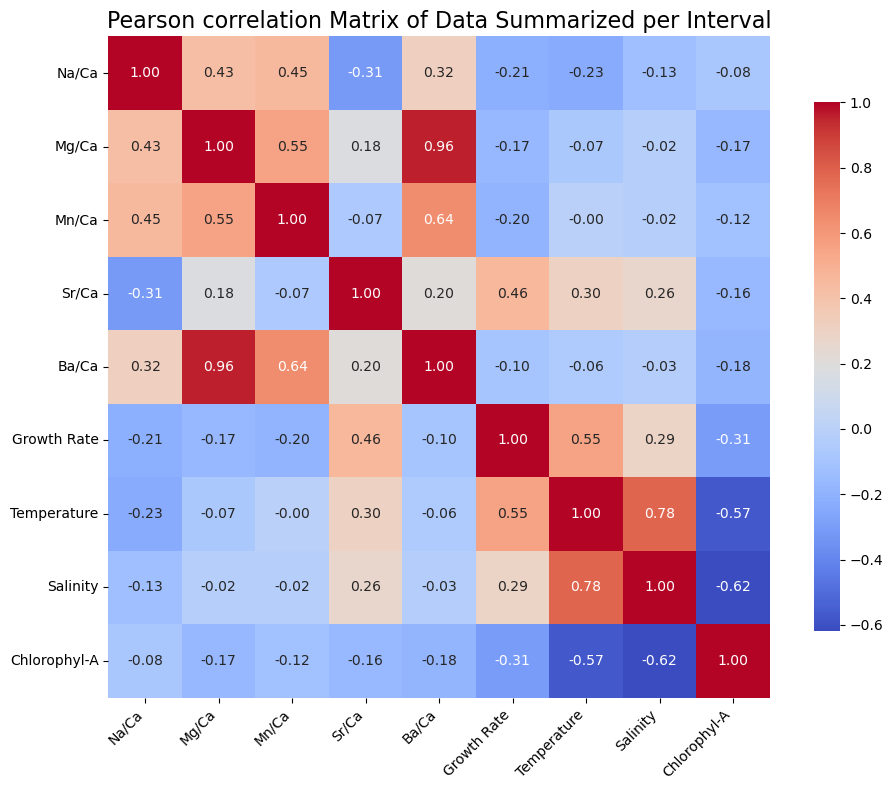

In [9]:
# Plot correlation matrix for data_summary
# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A',
    'growth_mean': 'Growth Rate'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Combine all display name mappings
all_display_names = {**predictor_display_names, **response_display_names}

# Isolate the relevant columns for the correlation matrix
correlation_columns = [
    'NaCa_mean',
    'MgCa_mean',
    'MnCa_mean',
    'SrCa_mean',
    'BaCa_mean',
    'growth_mean',
    'T_mean',
    'S_mean',
    'Chl_mean'
]
data_summary_trim = data_summary[correlation_columns]

# Compute correlation and apply renamed labels
corr = data_summary_trim.corr()
corr.rename(index=all_display_names, columns=all_display_names, inplace=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Pearson correlation Matrix of Data Summarized per Interval', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Plot Spearman correlation matrix

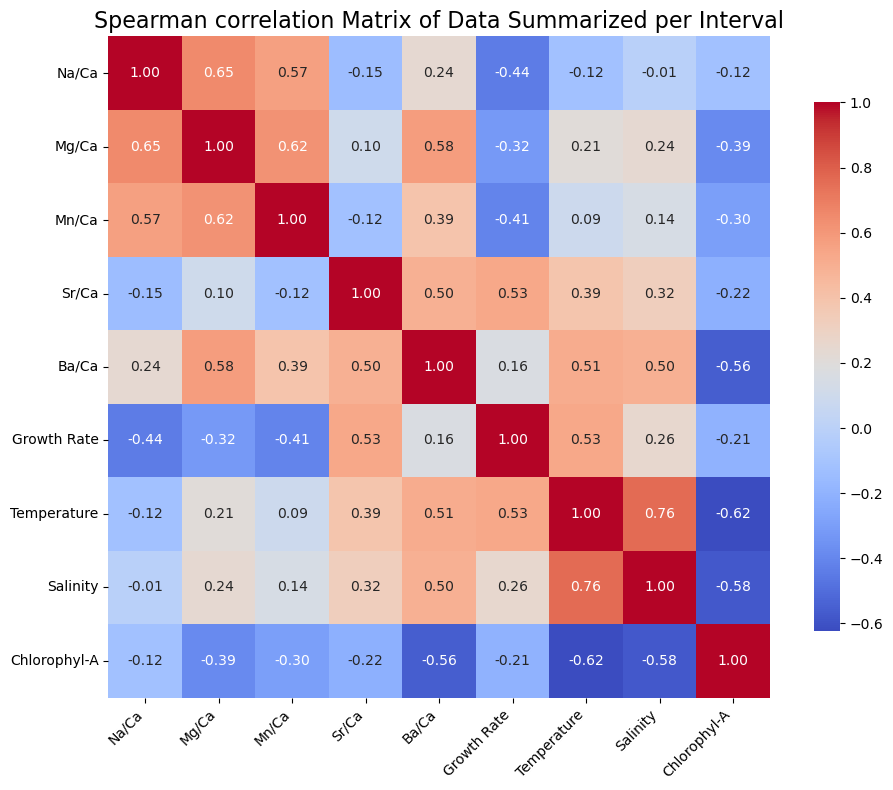

In [10]:
# Plot correlation matrix for data_summary
# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A',
    'growth_mean': 'Growth Rate'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Combine all display name mappings
all_display_names = {**predictor_display_names, **response_display_names}

# Isolate the relevant columns for the correlation matrix
correlation_columns = [
    'NaCa_mean',
    'MgCa_mean',
    'MnCa_mean',
    'SrCa_mean',
    'BaCa_mean',
    'growth_mean',
    'T_mean',
    'S_mean',
    'Chl_mean'
]
data_summary_trim = data_summary[correlation_columns]

# Compute correlation and apply renamed labels
corr_spearman = data_summary_trim.corr(method = 'spearman')
corr_spearman.rename(index=all_display_names, columns=all_display_names, inplace=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Spearman correlation Matrix of Data Summarized per Interval', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Pairwise scatter plots with errors and by-specimen statistics

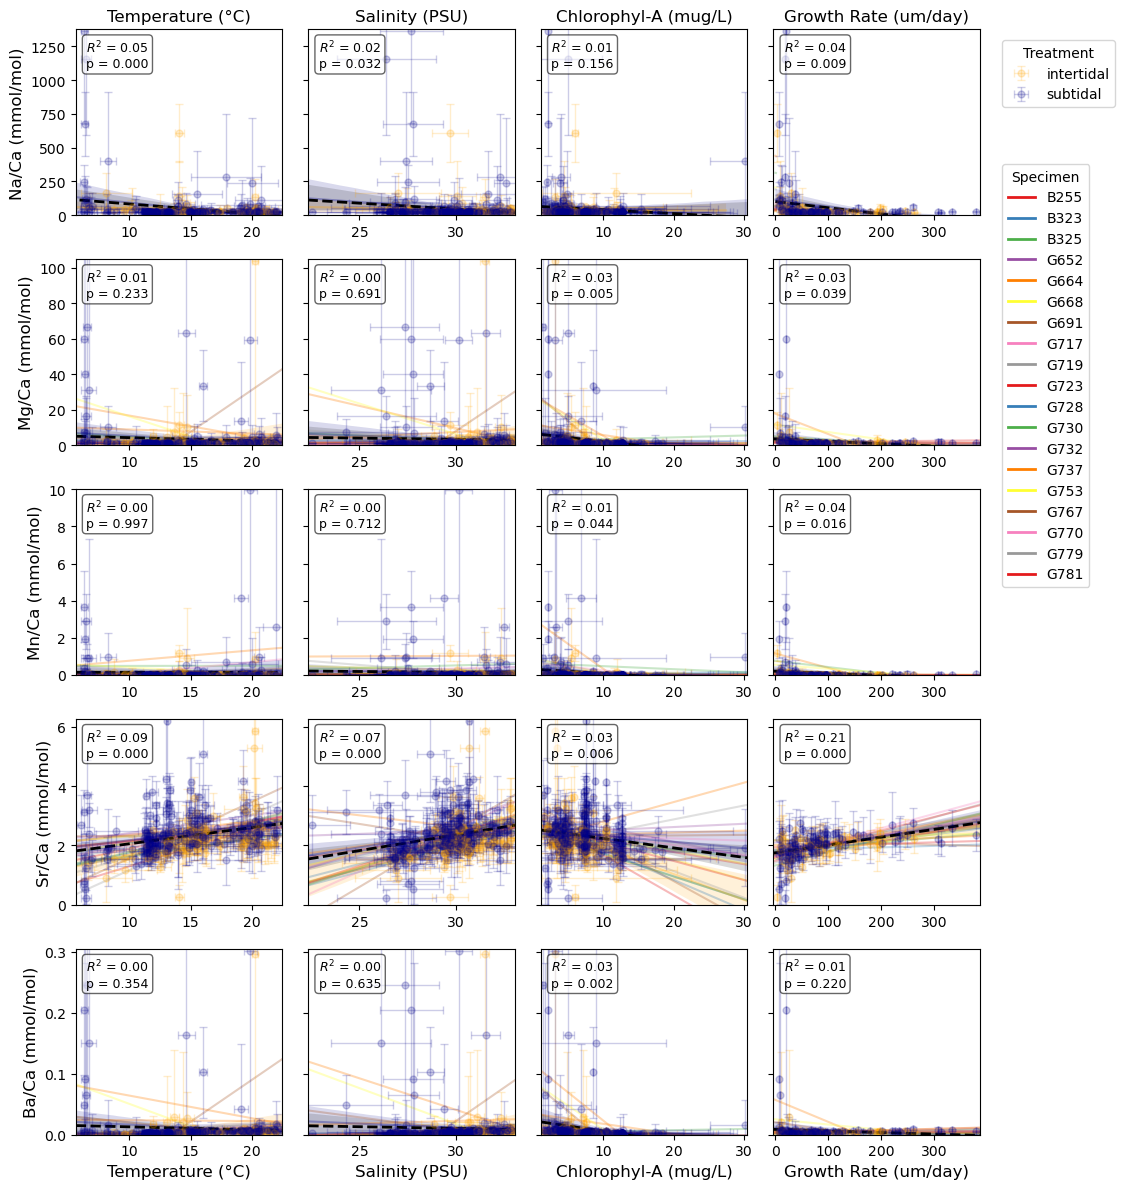

In [24]:
# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature (°C)',
    'S_mean': 'Salinity (PSU)',
    'Chl_mean': 'Chlorophyl-A (mug/L)',
    'growth_mean': 'Growth Rate (um/day)'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca (mmol/mol)',
    'MgCa_mean': 'Mg/Ca (mmol/mol)',
    'MnCa_mean': 'Mn/Ca (mmol/mol)',
    'SrCa_mean': 'Sr/Ca (mmol/mol)',
    'BaCa_mean': 'Ba/Ca (mmol/mol)'
}

predictor_names = {
    'T_mean': 'T_sd',
    'S_mean': 'S_sd',
    'Chl_mean': 'Chl_sd',
    'growth_mean': 'growth_sd'
}

response_names = {
    'NaCa_mean': 'NaCa_sd',
    'MgCa_mean': 'MgCa_sd',
    'MnCa_mean': 'MnCa_sd',
    'SrCa_mean': 'SrCa_sd',
    'BaCa_mean': 'BaCa_sd'
}

# Prepare data for pairwise scatter plots
predictors = list(predictor_names.keys())
responses = list(response_names.keys())

# Assign unique colors to each specimen
specimens = data_summary['specimen'].unique()
palette = sns.color_palette("Set1", n_colors=len(specimens))
specimen_colors = dict(zip(specimens, palette))

# Assign unique colors per treatment
treatments = data_summary['treatment'].unique()
treatment_colors = {'subtidal': 'darkblue', 'intertidal': 'orange'}

# Store regression stats
global_stats_lin_all = {}      # global regression stats
specimen_stats_lin_all = {}    # for export, not plotted
treatment_stats_lin_all = {}   # for export, not plotted

# Initialize the figure and axes for pairwise scatter plots
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12), sharex='col', sharey='row')

for i, response in enumerate(responses):
    for j, predictor in enumerate(predictors):
        ax = axs[i, j]
        # First plot per specimen
        for specimen in specimens:
            df_subset = data_summary[data_summary['specimen'] == specimen]
            # Plot regression line per specimen
            sns.regplot(
                x=predictor,
                y=response,
                data=df_subset,
                scatter=False,
                ax=ax,
                ci=None,
                color=specimen_colors[specimen],
                line_kws={"lw": 1.5, "alpha": 0.3},
                truncate=False
            )

            # Compute and store specimen-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                specimen_stats_lin_all[(response, predictor, specimen)] = {
                    'treatment': df_subset['treatment'].iloc[0],  # Store treatment for the specimen
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_regs),
                    'slope': model_s.params[predictor],
                    'intercept': model_s.params['const']
                }
            else:
                specimen_stats_lin_all[(response, predictor, specimen)] = {
                    'treatment': df_subset['treatment'].iloc[0],  # Store treatment for the specimen
                    'r2': np.nan,
                    'p': np.nan,
                    'n': 0,
                    'slope': np.nan,
                    'intercept': np.nan
                }
        # Secondly, plot per treatment
        for treatment in treatments:
            df_subset = data_summary[data_summary['treatment'] == treatment] # Isolate data per treatment group
            # Set color for the treatment
            color = treatment_colors[treatment]

            # Compute and store treatment-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                treatment_stats_lin_all[(response, predictor, treatment)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_regs),
                    'slope': model_s.params[predictor],
                    'intercept': model_s.params['const']
                }
            else:
                treatment_stats_lin_all[(response, predictor, treatment)] = {
                    'r2': np.nan,
                    'p': np.nan,
                    'n': 0,
                    'slope': np.nan,
                    'intercept': np.nan
                }

            # Extract x, y, and error values for the current specimen
            x = df_subset[predictor]
            y = df_subset[response]
            xerr = df_subset[predictor_names[predictor]]
            yerr = df_subset[response_names[response]]

            # Plot data points with error bars
            ax.errorbar(x,
                        y,
                        xerr=xerr,
                        yerr=yerr,
                        fmt='o',
                        color=color,
                        elinewidth=1,
                        alpha=0.2,
                        markersize=5,
                        capsize=3,
                        label=treatment if (i == 0 and j == 0) else None  # only label once for legend
            )

            # Plot regression line per treatment
            sns.regplot(
                x=predictor,
                y=response,
                data=df_subset,
                scatter=False,
                ax=ax,
                ci=95,
                color=treatment_colors[treatment],
                line_kws={"lw": 1.5, "alpha": 0.3},
                truncate=False
            )
            
        # # Plot global regression line (all specimens, use Ortogonal Distance Regression)
        # def f(B, x): # York regression function (linear)
        #     return B[0] * x + B[1]

        # # Get x, y, and their errors
        # x = data_summary[predictor].values
        # y = data_summary[response].values
        # xerr = data_summary[predictor_names[predictor]].values
        # yerr = data_summary[response_names[response]].values

        # # Remove NaNs
        # mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(xerr) & ~np.isnan(yerr)
        # x, y, xerr, yerr = x[mask], y[mask], xerr[mask], yerr[mask]

        # # Prepare data for ODR
        # data = RealData(x, y, sx=xerr, sy=yerr) # RealData object for ODR (x and y with their errors)
        # model = Model(f) # Model for ODR
        # odr = ODR(data, model, beta0=[0, np.mean(y)]) # ODR object with initial guess for parameters
        # output = odr.run() # Run the ODR

        # # Get fit line
        # x_fit = np.linspace(np.min(x), np.max(x), 200)
        # y_fit = output.beta[0] * x_fit + output.beta[1]

        # # Plot the York regression line
        # ax.plot(x_fit, y_fit, color='black', lw=2, ls='--', label='York fit')

        # # Optionally, add fit parameters to the plot
        # stat_text = f"York: y = {output.beta[0]:.3f}x + {output.beta[1]:.3f}"
        # ax.text(0.05, 0.85, stat_text, transform=ax.transAxes, va='top', ha='left',
        #         fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))

        # Plot global regression line
        sns.regplot(
            x=predictor,
            y=response,
            data=data_summary,
            scatter=False,
            ax=ax,
            ci=95,
            color='black',
            line_kws={"lw": 2, "ls": "--"},
            truncate=False
        )

        # Calculate global regression stats (R², p)
        df_reg = data_summary[[predictor, response]].dropna()
        X = sm.add_constant(df_reg[predictor])
        y = df_reg[response]
        if len(df_reg) > 2:
            model = sm.OLS(y, X).fit()
            r2 = model.rsquared
            pval = model.pvalues[predictor]
        else:
            r2, pval = np.nan, np.nan

        global_stats_lin_all[(response, predictor)] = {
            'r2': r2,
            'p': pval,
            'n': len(df_reg),
            'slope': model.params[predictor],
            'intercept': model.params['const']
        }

        # Annotate global stats
        stat_text = (f"$R^2$ = {r2:.2f}\np = {pval:.3f}"
             if not np.isnan(r2) and not np.isnan(pval)
             else "Insufficient data")
        ax.text(0.05, 0.95, stat_text,
                transform=ax.transAxes,
                va='top', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))
        
        # Set labels and titles only for the first row and first column
        if i == 0:
            ax.set_title(predictor_display_names[predictor], fontsize=12)
        if j == 0:
            ax.set_ylabel(response_display_names[response], fontsize=12)
        else:
            ax.set_ylabel('')
        
        # Set limits for y-axis based on data and lower bound at 0
        ax.set_ylim(
            0,
            data_summary[response].max() + 0.1 * data_summary[response].std()
        )
        # Set limits for x-axis based on data
        ax.set_xlim(
            data_summary[predictor].min() - 0.1 * data_summary[predictor].std(),
            data_summary[predictor].max() + 0.1 * data_summary[predictor].std()
        )

        # Set x-axis tick labels on all plots
        ax.tick_params(axis='x', which='both', labelbottom=True)

        # Remove x-axis labels for all but the last row
        if i < len(responses) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(predictor_display_names[predictor], fontsize=12)

# Add custom legend outside plot (only once)
# Treatment legend
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(1.0, 0.9), title="Treatment")

# Specimen legend
specimen_legend_handles = [
    Line2D([0], [0], color=specimen_colors[spec], lw=2, label=spec)
    for spec in specimens
]

# Add specimen legend to the left of the figure
fig.legend(
    handles=specimen_legend_handles,
    loc='lower left',
    bbox_to_anchor=(1.0, 0.5),
    title='Specimen',
    fontsize=10
)

plt.tight_layout()
plt.show()

### Export regression results

In [25]:
# Convert the regression stats to a DataFrame for easier export
global_stats_df = pd.DataFrame.from_dict(global_stats_lin_all, orient='index').reset_index()
global_stats_df.columns = ['response', 'predictor', 'r2', 'p', 'n' , 'slope', 'intercept']
# Export regression results to CSV
global_stats_df.to_csv("Global_regression_stats_linear_alldata.csv", index=False)

# Export specimen-specific regression stats to CSV
specimen_stats_df = pd.DataFrame.from_dict(specimen_stats_lin_all, orient='index').reset_index()
specimen_stats_df.columns = ['treatment', 'response', 'predictor', 'specimen', 'r2', 'p', 'n' , 'slope', 'intercept']
# Export to CSV
specimen_stats_df.to_csv("Specimen_regression_stats_linear_alldata.csv", index=False)

# Export treatment-specific regression stats to CSV
treatment_stats_df = pd.DataFrame.from_dict(treatment_stats_lin_all, orient='index').reset_index()
treatment_stats_df.columns = ['response', 'predictor', 'treatment', 'r2', 'p', 'n' , 'slope', 'intercept']
# Export to CSV
treatment_stats_df.to_csv("Treatment_regression_stats_linear_alldata.csv", index=False)

### Pairwise scatter plots with errors and by-specimen statistics and outlier removal

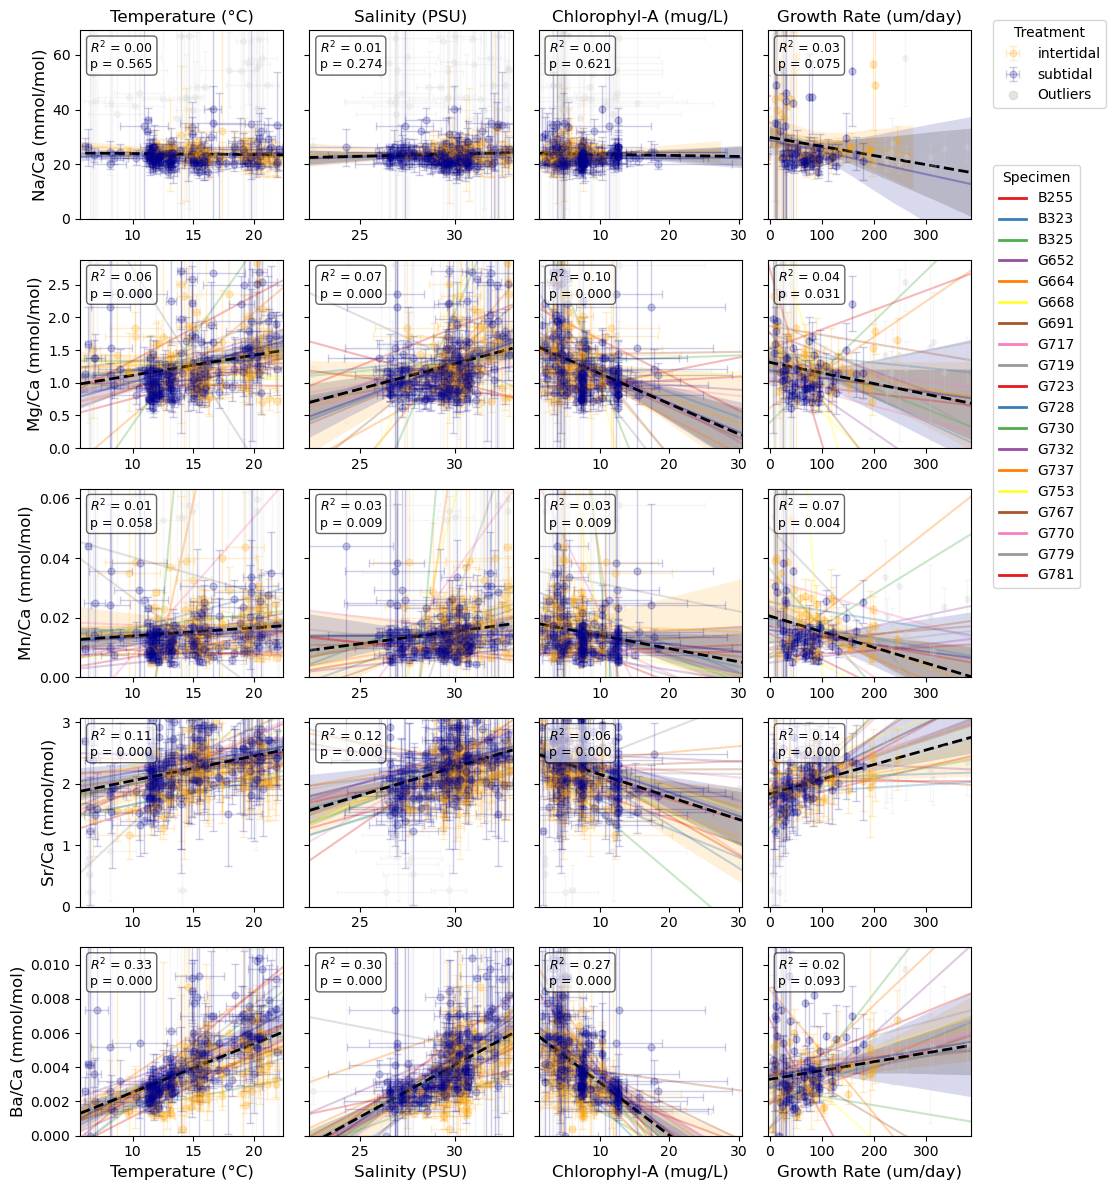

In [22]:
# Function to remove outliers based on the IQR method for both x and y (k = number of IQRs as benchmark)
def remove_outliers_iqr(df, x_col, y_col, k=1.5):
    """Remove outliers based on the IQR method for both x and y."""
    df = df[[x_col, y_col]].dropna()
    
    # X filtering
    Q1_x, Q3_x = df[x_col].quantile([0.25, 0.75])
    IQR_x = Q3_x - Q1_x
    x_mask = (df[x_col] >= Q1_x - k * IQR_x) & (df[x_col] <= Q3_x + k * IQR_x)

    # Y filtering
    Q1_y, Q3_y = df[y_col].quantile([0.25, 0.75])
    IQR_y = Q3_y - Q1_y
    y_mask = (df[y_col] >= Q1_y - k * IQR_y) & (df[y_col] <= Q3_y + k * IQR_y)

    # Combine masks
    return df[x_mask & y_mask]

# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature (°C)',
    'S_mean': 'Salinity (PSU)',
    'Chl_mean': 'Chlorophyl-A (mug/L)',
    'growth_mean': 'Growth Rate (um/day)'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca (mmol/mol)',
    'MgCa_mean': 'Mg/Ca (mmol/mol)',
    'MnCa_mean': 'Mn/Ca (mmol/mol)',
    'SrCa_mean': 'Sr/Ca (mmol/mol)',
    'BaCa_mean': 'Ba/Ca (mmol/mol)'
}

predictor_names = {
    'T_mean': 'T_sd',
    'S_mean': 'S_sd',
    'Chl_mean': 'Chl_sd',
    'growth_mean': 'growth_sd'
}

response_names = {
    'NaCa_mean': 'NaCa_sd',
    'MgCa_mean': 'MgCa_sd',
    'MnCa_mean': 'MnCa_sd',
    'SrCa_mean': 'SrCa_sd',
    'BaCa_mean': 'BaCa_sd'
}

# Prepare data for pairwise scatter plots
predictors = list(predictor_names.keys())
responses = list(response_names.keys())

# Assign unique colors to each specimen
specimens = data_summary['specimen'].unique()
palette = sns.color_palette("Set1", n_colors=len(specimens))
specimen_colors = dict(zip(specimens, palette))

# Assign unique colors per treatment
treatments = data_summary['treatment'].unique()
treatment_colors = {'subtidal': 'darkblue', 'intertidal': 'orange'}

# Store regression stats
global_stats_lin_outliers = {}      # global regression stats
specimen_stats_lin_outliers = {}    # for export, not plotted
treatment_stats_lin_outliers = {}   # for export, not plotted

# Initialize the figure and axes for pairwise scatter plots
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12), sharex='col', sharey='row')

for i, response in enumerate(responses):
    for j, predictor in enumerate(predictors):
        ax = axs[i, j]
        for specimen in specimens:
            df_subset_raw = data_summary[data_summary['specimen'] == specimen] # All data for the current specimen
            df_subset = remove_outliers_iqr(df_subset_raw, predictor, response) # Clean data
            # Plot regression line per specimen
            sns.regplot(
                x=predictor,
                y=response,
                data=df_subset,
                scatter=False,
                ax=ax,
                ci=None,
                color=specimen_colors[specimen],
                line_kws={"lw": 1.5, "alpha": 0.3},
                truncate=False
            )

            # Compute and store specimen-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                specimen_stats_lin_outliers[(response, predictor, specimen)] = {
                    'treatment': df_subset_raw['treatment'].iloc[0],  # Store treatment for the specimen
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_regs),
                    'slope': model_s.params[predictor],
                    'intercept': model_s.params['const']
                }
            else:
                specimen_stats_lin_outliers[(response, predictor, specimen)] = {
                    'treatment': df_subset_raw['treatment'].iloc[0],  # Store treatment for the specimen
                    'r2': np.nan,
                    'p': np.nan,
                    'n': 0,
                    'slope': np.nan,
                    'intercept': np.nan
                }
            
        # Secondly, plot per treatment
        for treatment in treatments:
            df_subset_raw = data_summary[data_summary['treatment'] == treatment] # Isolate data per treatment group
            df_subset = remove_outliers_iqr(df_subset_raw, predictor, response) # Clean data
            # Set color for the treatment
            color = treatment_colors[treatment]

            # Compute and store treatment-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                treatment_stats_lin_outliers[(response, predictor, treatment)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_regs),
                    'slope': model_s.params[predictor],
                    'intercept': model_s.params['const']
                }
            else:
                treatment_stats_lin_outliers[(response, predictor, treatment)] = {
                    'r2': np.nan,
                    'p': np.nan,
                    'n': 0,
                    'slope': np.nan,
                    'intercept': np.nan
                }

            # Extract x, y, and error values for the current specimen
            # Separate raw and filtered data
            x_raw = df_subset_raw[predictor]
            y_raw = df_subset_raw[response]
            x_clean = df_subset[predictor]
            y_clean = df_subset[response]
            xerr = df_subset_raw[predictor_names[predictor]]
            yerr = df_subset_raw[response_names[response]]

            # Mask inliers
            inlier_mask = df_subset_raw.index.isin(df_subset.index)

            # Plot outliers in light gray
            ax.errorbar(x_raw[~inlier_mask],
                        y_raw[~inlier_mask],
                        xerr=xerr[~inlier_mask],
                        yerr=yerr[~inlier_mask],
                        fmt='o',
                        color='lightgray',
                        elinewidth=1,
                        alpha=0.2,
                        markersize=4,
                        capsize=2)

            # Plot inliers with color
            ax.errorbar(x_clean,
                        y_clean,
                        xerr=xerr[inlier_mask],
                        yerr=yerr[inlier_mask],
                        fmt='o',
                        color=color,
                        elinewidth=1,
                        alpha=0.2,
                        markersize=5,
                        capsize=3,
                        label=treatment if (i == 0 and j == 0) else None)  # only label once for legend

            # Plot regression line per treatment
            sns.regplot(
                x=predictor,
                y=response,
                data=df_subset,
                scatter=False,
                ax=ax,
                ci=95,
                color=treatment_colors[treatment],
                line_kws={"lw": 1.5, "alpha": 0.3},
                truncate=False
            )
        
        # Prepare data for global regression line
        df_reg = remove_outliers_iqr(data_summary, predictor, response)
        
        # Plot global regression line (all specimens, use Ortogonal Distance Regression)
        # def f(B, x): # York regression function (linear)
        #     return B[0] * x + B[1]

        # # Get x, y, and their errors
        # x = data_summary[predictor].values
        # y = data_summary[response].values
        # xerr = data_summary[predictor_names[predictor]].values
        # yerr = data_summary[response_names[response]].values

        # # Remove NaNs
        # mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(xerr) & ~np.isnan(yerr)
        # x, y, xerr, yerr = x[mask], y[mask], xerr[mask], yerr[mask]

        # # Prepare data for ODR
        # data = RealData(x, y, sx=xerr, sy=yerr) # RealData object for ODR (x and y with their errors)
        # model = Model(f) # Model for ODR
        # odr = ODR(data, model, beta0=[0, np.mean(y)]) # ODR object with initial guess for parameters
        # output = odr.run() # Run the ODR

        # # Get fit line
        # x_fit = np.linspace(np.min(x), np.max(x), 200)
        # y_fit = output.beta[0] * x_fit + output.beta[1]

        # # Plot the York regression line
        # ax.plot(x_fit, y_fit, color='black', lw=2, ls='--', label='York fit')

        # # Optionally, add fit parameters to the plot
        # stat_text = f"York: y = {output.beta[0]:.3f}x + {output.beta[1]:.3f}"
        # ax.text(0.05, 0.85, stat_text, transform=ax.transAxes, va='top', ha='left',
        #         fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))

        # Plot global regression line (all specimens)
        df_reg = df_reg[[predictor, response]].dropna()
        sns.regplot(
            x=predictor,
            y=response,
            data=df_reg,
            scatter=False,
            ax=ax,
            ci=95,
            color='black',
            line_kws={"lw": 2, "ls": "--"},
            truncate=False
        )

        # Calculate global regression stats (R², p)
        X = sm.add_constant(df_reg[predictor])
        y = df_reg[response]
        if len(df_reg) > 2:
            model = sm.OLS(y, X).fit()
            r2 = model.rsquared
            pval = model.pvalues[predictor]
        else:
            r2, pval = np.nan, np.nan

        global_stats_lin_outliers[(response, predictor)] = {
            'r2': r2,
            'p': pval,
            'n': len(df_reg),
            'slope': model.params[predictor],
            'intercept': model.params['const']
        }

        # Annotate global stats
        stat_text = (f"$R^2$ = {r2:.2f}\np = {pval:.3f}"
             if not np.isnan(r2) and not np.isnan(pval)
             else "Insufficient data")
        ax.text(0.05, 0.95, stat_text,
                transform=ax.transAxes,
                va='top', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))
        
        # Set labels and titles only for the first row and first column
        if i == 0:
            ax.set_title(predictor_display_names[predictor], fontsize=12)
        if j == 0:
            ax.set_ylabel(response_display_names[response], fontsize=12)
        else:
            ax.set_ylabel('')
        
        # Set limits for y-axis based on data and lower bound at 0
        ax.set_ylim(
            0,
            df_reg[response].max() + df_reg[response].std()
        )
        # Set limits for x-axis based on data
        ax.set_xlim(
            data_summary[predictor].min() - 0.1 * data_summary[predictor].std(),
            data_summary[predictor].max() + 0.1 * data_summary[predictor].std()
        )

        # Set x-axis tick labels on all plots
        ax.tick_params(axis='x', which='both', labelbottom=True)

        # Remove x-axis labels for all but the last row
        if i < len(responses) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(predictor_display_names[predictor], fontsize=12)

# Add legend outside plot (only once)
handles, labels = axs[0, 0].get_legend_handles_labels()
# Add outlier legend handle (grey dot)
outlier_handle = Line2D([0], [0], marker='o', color='lightgray', label='Outliers',
                        linestyle='None', markersize=6, markerfacecolor='lightgray', alpha=0.6)
# Append to handles
handles.append(outlier_handle)
labels.append('Outliers')
fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(1.0, 0.9), title="Treatment")

# Specimen legend
specimen_legend_handles = [
    Line2D([0], [0], color=specimen_colors[spec], lw=2, label=spec)
    for spec in specimens
]

# Add specimen legend to the left of the figure
fig.legend(
    handles=specimen_legend_handles,
    loc='lower left',
    bbox_to_anchor=(1.0, 0.5),
    title='Specimen',
    fontsize=10
)

plt.tight_layout()
plt.show()

### Export regression results after outlier removal

In [34]:
# Convert the regression stats to a DataFrame for easier export
global_stats_df = pd.DataFrame.from_dict(global_stats_lin_outliers, orient='index').reset_index()
global_stats_df.columns = ['response', 'predictor', 'r2', 'p', 'n' , 'slope', 'intercept']
# Export regression results to CSV
global_stats_df.to_csv("Global_regression_stats_linear_outliers.csv", index=False)

# Export specimen-specific regression stats to CSV
specimen_stats_df = pd.DataFrame.from_dict(specimen_stats_lin_outliers, orient='index').reset_index()
specimen_stats_df.columns = ['response', 'predictor', 'specimen', 'treatment', 'r2', 'p', 'n' , 'slope', 'intercept']
# Export to CSV
specimen_stats_df.to_csv("Specimen_regression_stats_linear_outliers.csv", index=False)

# Export treatment-specific regression stats to CSV
treatment_stats_df = pd.DataFrame.from_dict(treatment_stats_lin_outliers, orient='index').reset_index()
treatment_stats_df.columns = ['response', 'predictor', 'treatment', 'r2', 'p', 'n' , 'slope', 'intercept']
# Export to CSV
treatment_stats_df.to_csv("Treatment_regression_stats_linear_outliers.csv", index=False)

### Plot effect size (slope) distribution over specimens and treatments

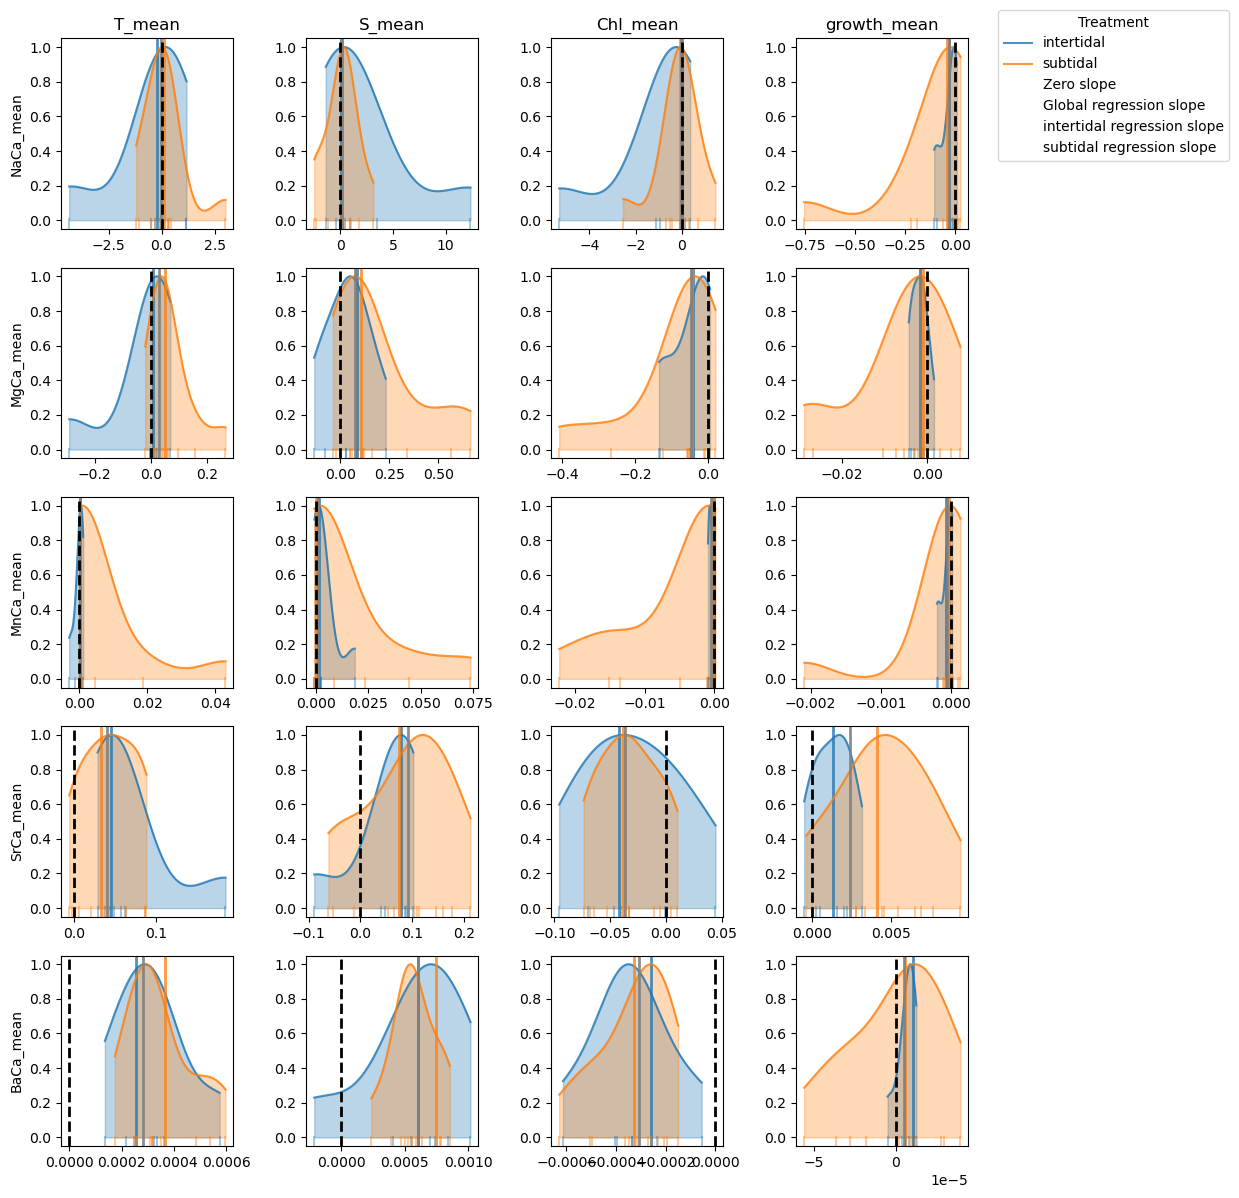

In [72]:
# Plot distribution of slopes of linear regression for each combination of response and predictor, colored by treatment

# Catch legend handles and labels
legend_handles = []
legend_labels = []

# Create dummy vertical lines for the per-treatment regression slopes here
dummy_regression_lines = {}

# Initialize the figure and axes for pairwise scatter plots
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12))

for i, resp in enumerate(responses):
    for j, pred in enumerate(predictors):
        ax = axs[i, j]
        # Loop over treatments
        for t_idx, treatment in enumerate(treatments):
            mask = ( # Filter for the specific response, predictor, and treatment
                (specimen_stats_df['predictor'] == pred) &
                (specimen_stats_df['response'] == resp) &
                (specimen_stats_df['treatment'] == treatment)
            )
            slopes = specimen_stats_df.loc[mask, 'slope'].tolist()
            # ax.hist(slopes, bins=20, alpha=0.5, label=treatment, density=True)
            if len(slopes) > 1:  # KDE needs more than one point
                # KDE calculation
                kde = gaussian_kde(slopes)
                x_vals = np.linspace(min(slopes), max(slopes), 200)
                y_vals = kde(x_vals)
                y_vals /= y_vals.max()  # normalize to 0–1

                line, = ax.plot(x_vals, y_vals, color=sns.color_palette()[list(treatments).index(treatment)],
                        label=treatment if (i == 0 and j == 0) else None, alpha=0.8)
                ax.fill_between(x_vals, y_vals, alpha=0.3,
                                color=sns.color_palette()[list(treatments).index(treatment)])
                
                if i == 0 and j == 0:
                    legend_handles.append(line)
                    legend_labels.append(treatment)
            
            # Vertical bars for individual values
            for s in slopes:
                ax.axvline(s, color=sns.color_palette()[list(treatments).index(treatment)],
                            linestyle='-', alpha=0.4, ymin=0, ymax=0.05)  # short bar at bottom
            
            # Per-treatment regression slope line from treatment_stats_df
            treatment_mask = (
                (treatment_stats_df['predictor'] == pred) &
                (treatment_stats_df['response'] == resp) &
                (treatment_stats_df['treatment'] == treatment)
            )
            if not treatment_stats_df.loc[treatment_mask, 'slope'].empty:
                reg_slope = treatment_stats_df.loc[treatment_mask, 'slope'].iloc[0]
                ax.axvline(
                    reg_slope,
                    color=sns.color_palette()[list(treatments).index(treatment)],
                    linestyle='-',
                    linewidth=2,
                    alpha=0.8
                )

                # Create dummy regression line for legend once (on first subplot)
                if i == 0 and j == 0 and treatment not in dummy_regression_lines:
                    temp_ax = axs[0, 0]
                    dummy_line = temp_ax.axvline(
                        0,  # dummy x-position for legend
                        color=sns.color_palette()[t_idx],
                        linestyle='-',
                        linewidth=2,
                        alpha=0.8,
                        visible=False  # hide it on plot
                    )
                    dummy_regression_lines[treatment] = dummy_line

        # Grey dashed total regression slope from global_stats_df
        global_mask = (
            (global_stats_df['predictor'] == pred) &
            (global_stats_df['response'] == resp)
        )
        if not global_stats_df.loc[global_mask, 'slope'].empty:
            global_slope = global_stats_df.loc[global_mask, 'slope'].iloc[0]
            ax.axvline(
                global_slope,
                color='grey',
                linestyle='-',
                linewidth=2,
                alpha=0.9
            )

        # Add black dotted line at slope = 0
        ax.axvline(0, color='black', linestyle='--', linewidth=2)

        # Titles & labels
        if i == 0:
            ax.set_title(pred)
        if j == 0:
            ax.set_ylabel(resp)

# Use one axis to create dummy lines for legend handles
temp_ax = axs[0, 0]

# Create zero slope line handle
zero_line = temp_ax.axvline(0, color='black', linestyle='--', linewidth=1.2, visible=False)
# Create global slope line handle (example at x=0 just for legend, actual position doesn't matter)
global_line = temp_ax.axvline(0, color='grey', linestyle='--', linewidth=1.5, alpha=0.9, visible=False)

# Append these handles and labels
legend_handles.extend([zero_line, global_line])
legend_labels.extend(['Zero slope', 'Global regression slope'])

# Add dummy regression slope lines for each treatment to legend
for treatment, dummy_line in dummy_regression_lines.items():
    legend_handles.append(dummy_line)
    legend_labels.append(f'{treatment} regression slope')

# Create one global legend for the figure
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Treatment",
    loc="upper right",
    bbox_to_anchor=(1.25, 1)
)

plt.tight_layout()
plt.show()

### Pairwise scatterplots with log-transformed response variables

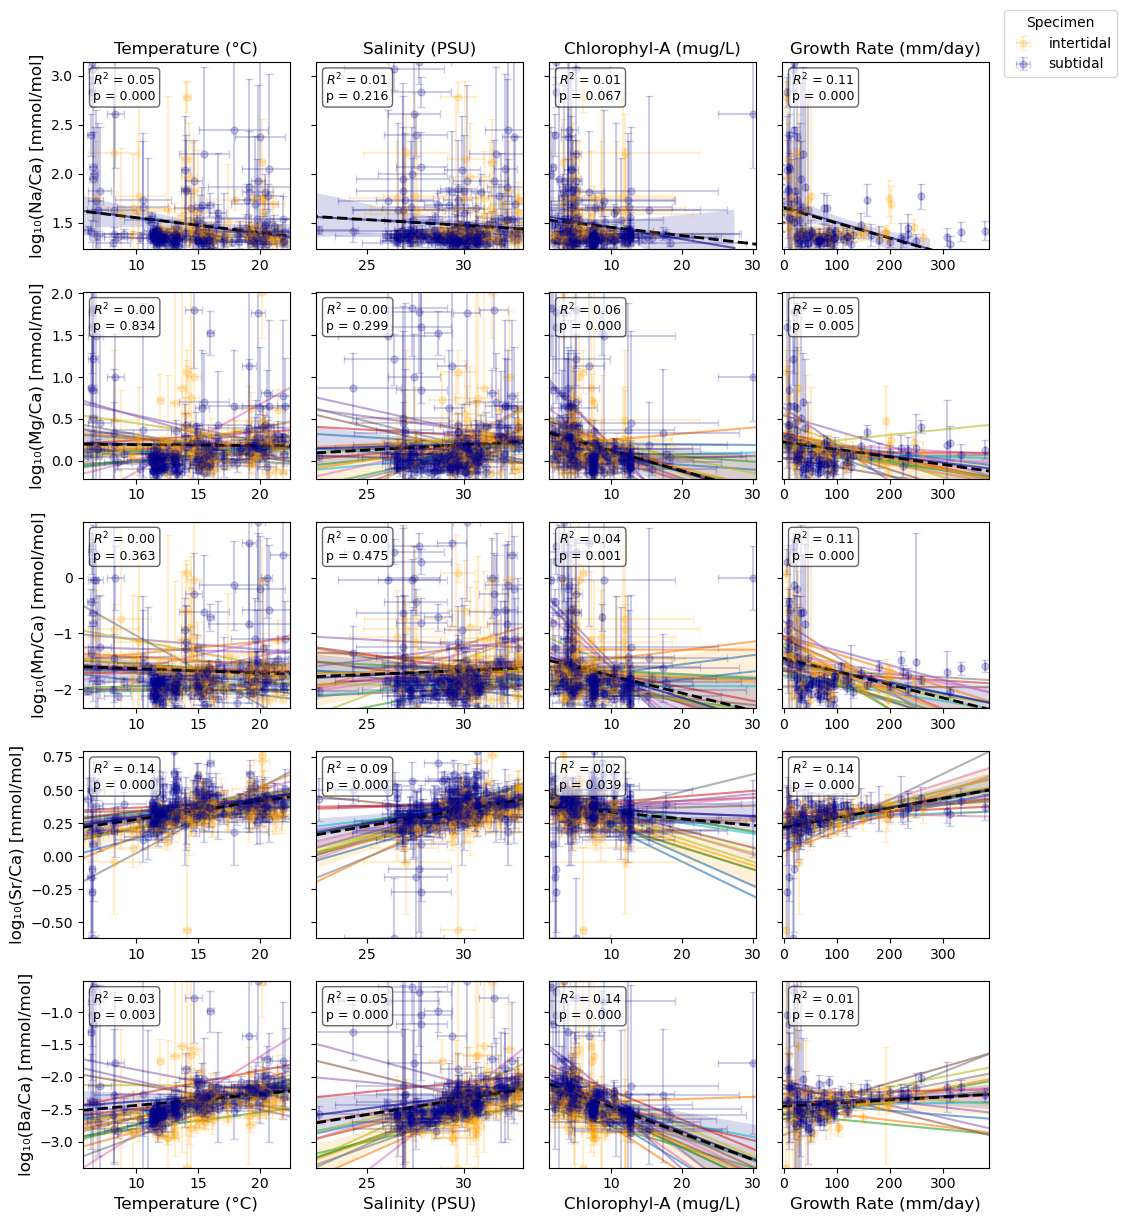

In [75]:
# Mappings and setup
predictor_errors = {
    'T_mean': 'T_sd',
    'S_mean': 'S_sd',
    'Chl_mean': 'Chl_sd',
    'growth_mean': 'growth_sd'
}

response_errors = {
    'NaCa_mean': 'NaCa_sd',
    'MgCa_mean': 'MgCa_sd',
    'MnCa_mean': 'MnCa_sd',
    'SrCa_mean': 'SrCa_sd',
    'BaCa_mean': 'BaCa_sd'
}

predictor_display_names = {
    'T_mean': 'Temperature (°C)',
    'S_mean': 'Salinity (PSU)',
    'Chl_mean': 'Chlorophyl-A (mug/L)',
    'growth_mean': 'Growth Rate (mm/day)'
}

response_display_names = {
    'NaCa_mean': 'log₁₀(Na/Ca) [mmol/mol]',
    'MgCa_mean': 'log₁₀(Mg/Ca) [mmol/mol]',
    'MnCa_mean': 'log₁₀(Mn/Ca) [mmol/mol]',
    'SrCa_mean': 'log₁₀(Sr/Ca) [mmol/mol]',
    'BaCa_mean': 'log₁₀(Ba/Ca) [mmol/mol]'
}

predictors = list(predictor_errors.keys())
responses = list(response_errors.keys())
specimens = data_summary['specimen'].unique()
palette = sns.color_palette("tab10", len(specimens))
specimen_colors = dict(zip(specimens, palette))
treatments = data_summary['treatment'].unique()
treatment_colors = {'subtidal': 'darkblue', 'intertidal': 'orange'}

# Create figure
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12), sharex='col', sharey='row')

# Regression stats storage
global_stats_log_all = {}
specimen_stats_log_all = {}
treatment_stats_log_all = {}

# Iterate through plots
for i, response in enumerate(responses):
    for j, predictor in enumerate(predictors):
        ax = axs[i, j]

        # Drop non-positive or missing response values for log-transform
        df_valid = data_summary[[predictor, response, 'specimen', 'treatment',
                         predictor_errors[predictor], response_errors[response]]].copy()
        df_valid = df_valid[df_valid[response] > 0].dropna()

        # Log-transform the response
        df_valid[f'log_{response}'] = np.log10(df_valid[response])

        # Plot shaded regressions by specimen
        for specimen in specimens:
            df_subset = df_valid[df_valid['specimen'] == specimen]
            if len(df_subset) > 2:
                sns.regplot(
                    x=predictor, y=f'log_{response}', data=df_subset,
                    scatter=False, ax=ax,
                    ci=None, color=specimen_colors[specimen],
                    line_kws={"lw": 1.5, "alpha": 0.6}, truncate=False
                )

                # Regression stats (specimen)
                Xs = sm.add_constant(df_subset[predictor])
                ys = df_subset[f'log_{response}']
                model_s = sm.OLS(ys, Xs).fit()
                specimen_stats_log_all[(response, predictor, specimen)] = {
                    'treatment': df_subset['treatment'].iloc[0],  # Store treatment for the specimen
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_subset),
                    'slope': model_s.params[predictor],
                    'intercept': model_s.params['const']
                }
        
        for treatment in treatments:
            df_subset = df_valid[df_valid['treatment'] == treatment]
            if len(df_subset) > 2:
                sns.regplot(
                    x=predictor, y=f'log_{response}', data=df_subset,
                    scatter=False, ax=ax,
                    ci=95, color=treatment_colors[treatment],
                    line_kws={"lw": 1.5, "alpha": 0.6}, truncate=False
                )

                # Regression stats (treatment)
                Xs = sm.add_constant(df_subset[predictor])
                ys = df_subset[f'log_{response}']
                model_s = sm.OLS(ys, Xs).fit()
                treatment_stats_log_all[(response, predictor, treatment)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_subset),
                    'slope': model_s.params[predictor],
                    'intercept': model_s.params['const']
                }
            # Plot error bars (original response, but log y)
            if not df_subset.empty:
                y_log = np.log10(df_subset[response])
                y_log_err = (df_subset[response_errors[response]] / df_subset[response]) / np.log(10)

                ax.errorbar(
                    df_subset[predictor], y_log,
                    xerr=df_subset[predictor_errors[predictor]],
                    yerr=y_log_err,
                    fmt='o', color=treatment_colors[treatment],
                    ecolor=treatment_colors[treatment],
                    alpha=0.2, capsize=3, markersize=5,
                    label=treatment if (i == 0 and j == 0) else None
                )

        # Global regression (log-transformed response)
        if len(df_valid) > 2:
            X = sm.add_constant(df_valid[predictor])
            y = df_valid[f'log_{response}']
            model = sm.OLS(y, X).fit()
            r2 = model.rsquared
            pval = model.pvalues[predictor]

            global_stats_log_all[(response, predictor)] = {
                'r2': r2,
                'p': pval,
                'n': len(df_valid),
                'slope': model.params[predictor],
                'intercept': model.params['const']
            }

            # Plot global regression
            sns.regplot(
                x=predictor, y=f'log_{response}', data=df_valid,
                scatter=False, ax=ax,
                ci=None, color='black',
                line_kws={"lw": 2, "ls": "--"}, truncate=False
            )
        else:
            r2, pval = np.nan, np.nan

        # Annotate global regression stats
        stat_text = (f"$R^2$ = {r2:.2f}\np = {pval:.3f}"
                     if not np.isnan(r2) and not np.isnan(pval)
                     else "Insufficient data")

        ax.text(0.05, 0.95, stat_text,
                transform=ax.transAxes,
                va='top', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))

        # Axis labels
        if i == 0:
            ax.set_title(predictor_display_names[predictor], fontsize=12)
        else:
            ax.set_title("")
        if j == 0:
            ax.set_ylabel(response_display_names[response], fontsize=12)
        else:
            ax.set_ylabel('')
        
        # Set limits for y-axis based on data rounded to next whole number
        ax.set_ylim(
            np.log10(data_summary[response][np.isfinite(data_summary[response]) & (data_summary[response] > 0)].min()),
            np.log10(data_summary[response][np.isfinite(data_summary[response]) & (data_summary[response] > 0)].max())
        )
        # Set limits for x-axis based on data
        ax.set_xlim(
            data_summary[predictor].min() - 0.1 * data_summary[predictor].std(),
            data_summary[predictor].max() + 0.1 * data_summary[predictor].std()
        )

        ax.tick_params(axis='x', which='both', labelbottom=True)

        # Remove x-axis labels for all but the last row
        if i < len(responses) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(predictor_display_names[predictor], fontsize=12)

# Legend
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Specimen", loc='upper right', bbox_to_anchor=(1.12, 1.02))

plt.tight_layout()
plt.show()

### Export regression results after log conversion

In [79]:
# Convert the regression stats to a DataFrame for easier export
global_stats_df = pd.DataFrame.from_dict(global_stats_log_all, orient='index').reset_index()
global_stats_df.columns = ['response', 'predictor', 'r2', 'p', 'n', 'slope', 'intercept']
# Export regression results to CSV
global_stats_df.to_csv("Global_regression_stats_log_all.csv", index=False)

# Export specimen-specific regression stats to CSV
specimen_stats_df = pd.DataFrame.from_dict(specimen_stats_log_all, orient='index').reset_index()
specimen_stats_df.columns = ['response', 'predictor', 'specimen', 'treatment', 'r2', 'p', 'n', 'slope', 'intercept']
# Export to CSV
specimen_stats_df.to_csv("Specimen_regression_stats_log_all.csv", index=False)

# Export treatment-specific regression stats to CSV
treatment_stats_df = pd.DataFrame.from_dict(treatment_stats_log_all, orient='index').reset_index()
treatment_stats_df.columns = ['response', 'predictor', 'treatment', 'r2', 'p', 'n', 'slope', 'intercept']
# Export to CSV
treatment_stats_df.to_csv("treatment_regression_stats_log_all.csv", index=False)

### Plot effect size (slope) distribution over specimens and treatments (log-lin regression)

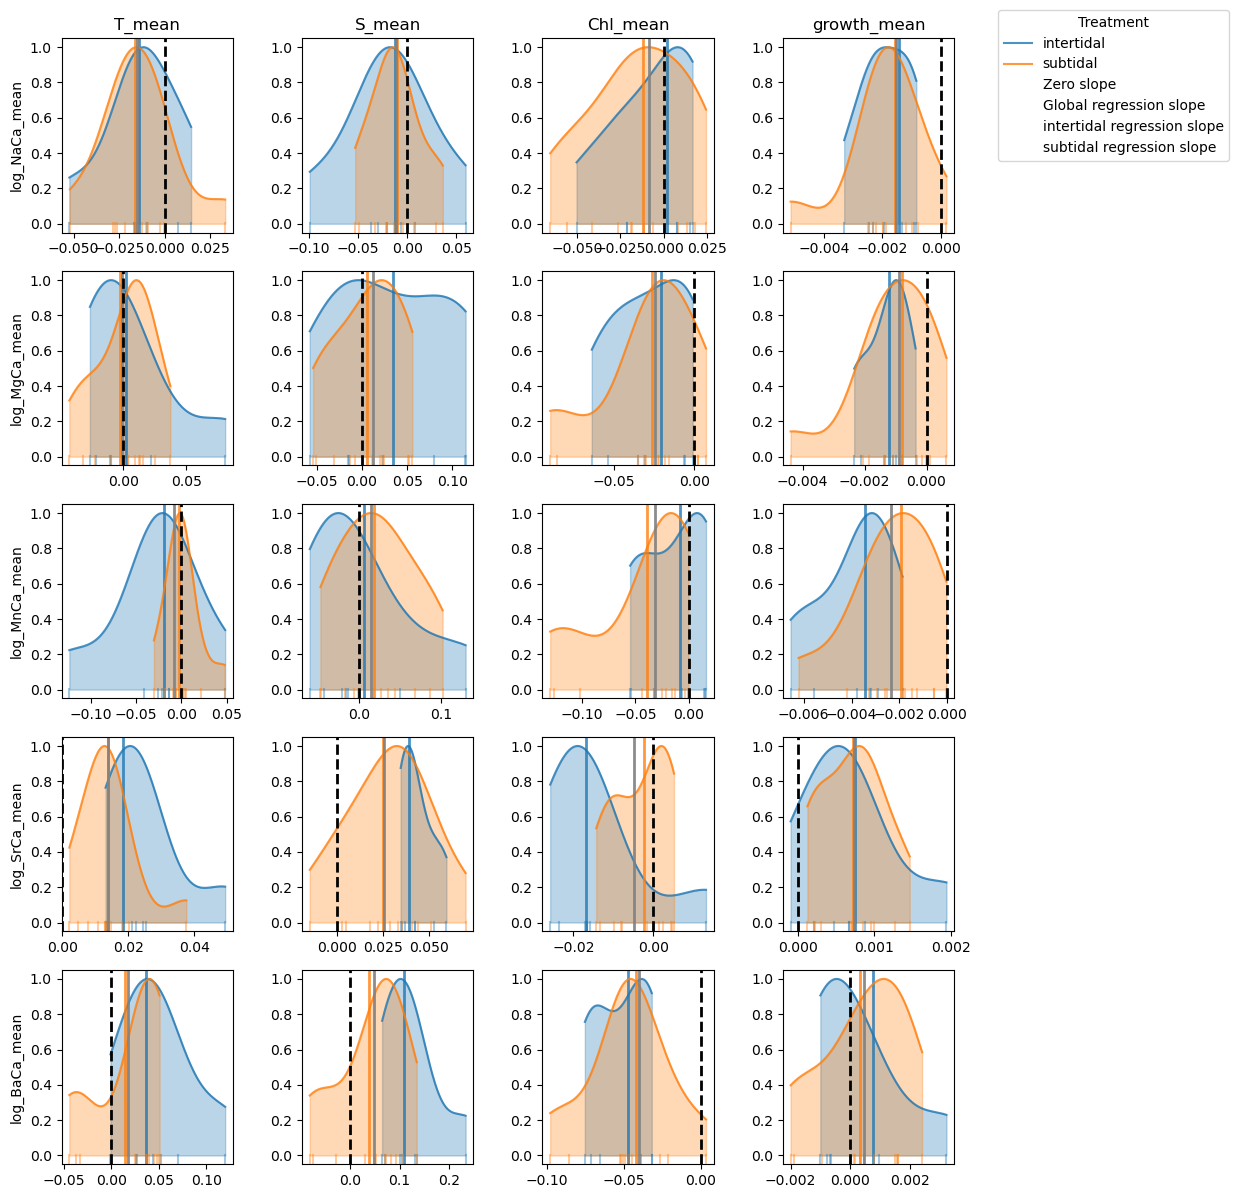

In [81]:
# Plot distribution of slopes of linear regression for each combination of response and predictor, colored by treatment

# Catch legend handles and labels
legend_handles = []
legend_labels = []

# Create dummy vertical lines for the per-treatment regression slopes here
dummy_regression_lines = {}

# Initialize the figure and axes for pairwise scatter plots
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12))

for i, resp in enumerate(responses):
    for j, pred in enumerate(predictors):
        ax = axs[i, j]
        # Loop over treatments
        for t_idx, treatment in enumerate(treatments):
            mask = ( # Filter for the specific response, predictor, and treatment
                (specimen_stats_df['predictor'] == pred) &
                (specimen_stats_df['response'] == resp) &
                (specimen_stats_df['treatment'] == treatment)
            )
            slopes = specimen_stats_df.loc[mask, 'slope'].tolist()
            # ax.hist(slopes, bins=20, alpha=0.5, label=treatment, density=True)
            if len(slopes) > 1:  # KDE needs more than one point
                # KDE calculation
                kde = gaussian_kde(slopes)
                x_vals = np.linspace(min(slopes), max(slopes), 200)
                y_vals = kde(x_vals)
                y_vals /= y_vals.max()  # normalize to 0–1

                line, = ax.plot(x_vals, y_vals, color=sns.color_palette()[list(treatments).index(treatment)],
                        label=treatment if (i == 0 and j == 0) else None, alpha=0.8)
                ax.fill_between(x_vals, y_vals, alpha=0.3,
                                color=sns.color_palette()[list(treatments).index(treatment)])
                
                if i == 0 and j == 0:
                    legend_handles.append(line)
                    legend_labels.append(treatment)
            
            # Vertical bars for individual values
            for s in slopes:
                ax.axvline(s, color=sns.color_palette()[list(treatments).index(treatment)],
                            linestyle='-', alpha=0.4, ymin=0, ymax=0.05)  # short bar at bottom
            
            # Per-treatment regression slope line from treatment_stats_df
            treatment_mask = (
                (treatment_stats_df['predictor'] == pred) &
                (treatment_stats_df['response'] == resp) &
                (treatment_stats_df['treatment'] == treatment)
            )
            if not treatment_stats_df.loc[treatment_mask, 'slope'].empty:
                reg_slope = treatment_stats_df.loc[treatment_mask, 'slope'].iloc[0]
                ax.axvline(
                    reg_slope,
                    color=sns.color_palette()[list(treatments).index(treatment)],
                    linestyle='-',
                    linewidth=2,
                    alpha=0.8
                )

                # Create dummy regression line for legend once (on first subplot)
                if i == 0 and j == 0 and treatment not in dummy_regression_lines:
                    temp_ax = axs[0, 0]
                    dummy_line = temp_ax.axvline(
                        0,  # dummy x-position for legend
                        color=sns.color_palette()[t_idx],
                        linestyle='-',
                        linewidth=2,
                        alpha=0.8,
                        visible=False  # hide it on plot
                    )
                    dummy_regression_lines[treatment] = dummy_line

        # Grey dashed total regression slope from global_stats_df
        global_mask = (
            (global_stats_df['predictor'] == pred) &
            (global_stats_df['response'] == resp)
        )
        if not global_stats_df.loc[global_mask, 'slope'].empty:
            global_slope = global_stats_df.loc[global_mask, 'slope'].iloc[0]
            ax.axvline(
                global_slope,
                color='grey',
                linestyle='-',
                linewidth=2,
                alpha=0.9
            )

        # Add black dotted line at slope = 0
        ax.axvline(0, color='black', linestyle='--', linewidth=2)

        # Titles & labels
        if i == 0:
            ax.set_title(pred)
        if j == 0:
            ax.set_ylabel('log_' + resp)

# Use one axis to create dummy lines for legend handles
temp_ax = axs[0, 0]

# Create zero slope line handle
zero_line = temp_ax.axvline(0, color='black', linestyle='--', linewidth=1.2, visible=False)
# Create global slope line handle (example at x=0 just for legend, actual position doesn't matter)
global_line = temp_ax.axvline(0, color='grey', linestyle='--', linewidth=1.5, alpha=0.9, visible=False)

# Append these handles and labels
legend_handles.extend([zero_line, global_line])
legend_labels.extend(['Zero slope', 'Global regression slope'])

# Add dummy regression slope lines for each treatment to legend
for treatment, dummy_line in dummy_regression_lines.items():
    legend_handles.append(dummy_line)
    legend_labels.append(f'{treatment} regression slope')

# Create one global legend for the figure
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Treatment",
    loc="upper right",
    bbox_to_anchor=(1.25, 1)
)

plt.tight_layout()
plt.show()

## Multivariate linear regression models

### Linear regressions of all elements based on summary data

In [82]:
# Set up a multiple regression model using statsmodels
# Using elemental ratios as outcome variable and growth rate, temperature, and salinity as predictors

# Define the outcome variables
outcome_vars = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']
predictors = ['growth_mean', 'T_mean', 'S_mean', 'Chl_mean']

# Initialize an empty list
results_list_summarized = []

for element in outcome_vars:
    # Prepare the data for regression
    X = data_summary[predictors].dropna()
    y = data_summary[element]
    
    # Combine the predictors and outcome variable
    data_regression = pd.concat([X, y], axis=1).dropna()
    X = data_regression[predictors]
    y = data_regression[element]

    # Add a constant to the predictors
    X = sm.add_constant(X)
    
    # Fit the regression model
    model = sm.OLS(y, X).fit()

    # Inside your loop
    results_list_summarized.append({
        'Element': element,
        'GR_slope': model.params[1],
        'GR_slope_se': model.bse[1],
        'T_slope': model.params[2],
        'T_slope_se': model.bse[2],
        'S_slope': model.params[3],
        'S_slope_se': model.bse[3],
        'Chl_slope': model.params[4],
        'Chl_slope_se': model.bse[4],
        'GR_slope_norm': model.params[1] / y.mean(),
        'GR_slope_norm_se': model.bse[1] / y.mean(),
        'T_slope_norm': model.params[2] / y.mean(),
        'T_slope_norm_se': model.bse[2] / y.mean(),
        'S_slope_norm': model.params[3] / y.mean(),
        'S_slope_norm_se': model.bse[3] / y.mean(),
        'Chl_slope_norm': model.params[4] / y.mean(),
        'Chl_slope_norm_se': model.bse[4] / y.mean(),
        'Intercept': model.params[0],
        'R_squared': model.rsquared,
        'P_value': model.pvalues[1],
        'Std_err': model.bse[1],
        'RSE': model.bse[1] / y.mean(),
    })

# After the loop, create DataFrame
regression_results_summarized = pd.DataFrame(results_list_summarized)

# Display the regression results
print(regression_results_summarized)

     Element  GR_slope  GR_slope_se    T_slope  T_slope_se    S_slope  \
0  NaCa_mean -0.187635     0.191501 -19.307475    5.816508 -17.182306   
1  MgCa_mean -0.002157     0.007193  -0.804110    0.218479  -0.283038   
2  MnCa_mean -0.000423     0.000510  -0.050057    0.015490  -0.043637   
3  SrCa_mean  0.001400     0.000436   0.042467    0.013247   0.100106   
4  BaCa_mean  0.000011     0.000023  -0.002628    0.000704  -0.000158   

   S_slope_se  Chl_slope  Chl_slope_se  GR_slope_norm  ...  T_slope_norm_se  \
0   13.191575 -29.415271      4.452285      -0.003006  ...         0.093193   
1    0.495501  -1.026197      0.167236      -0.000935  ...         0.094674   
2    0.035132  -0.076182      0.011857      -0.004022  ...         0.147362   
3    0.030044   0.048802      0.010140       0.000709  ...         0.006712   
4    0.001596  -0.003058      0.000539       0.001647  ...         0.107884   

   S_slope_norm  S_slope_norm_se  Chl_slope_norm  Chl_slope_norm_se  \
0     -0.275297

C:\Users\nwi213\AppData\Local\Temp\ipykernel_14596\2674666522.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'GR_slope': model.params[1],
C:\Users\nwi213\AppData\Local\Temp\ipykernel_14596\2674666522.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'GR_slope_se': model.bse[1],
C:\Users\nwi213\AppData\Local\Temp\ipykernel_14596\2674666522.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'T_slope': model.params[2],
C:\Us

### Plot effect sizes of predictors

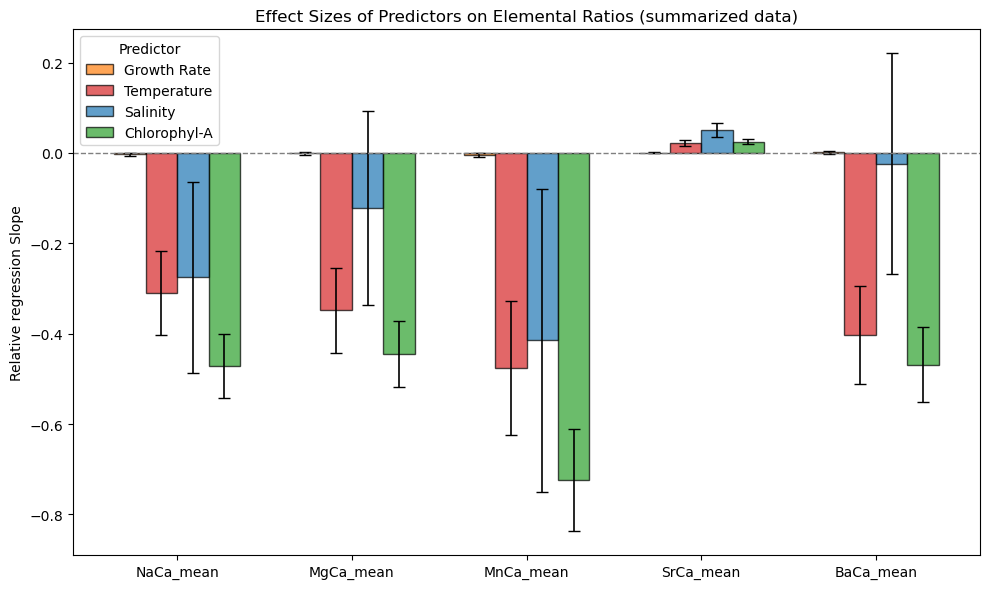

In [85]:
# Reshape the regression results to long format
effect_sizes_summarized = regression_results_summarized.melt(
    id_vars='Element',
    value_vars=['GR_slope_norm', 'T_slope_norm', 'S_slope_norm', 'Chl_slope_norm'],
    var_name='Predictor',
    value_name='EffectSize'
)

# Reshape regression slope standard errors to long format
effect_sizes_summarized_se = regression_results_summarized.melt(
    id_vars='Element',
    value_vars=['GR_slope_norm_se', 'T_slope_norm_se', 'S_slope_norm_se', 'Chl_slope_norm_se'],
    var_name='Predictor',
    value_name='SE'
)

# Ensure the predictors align for mapping and merging
predictor_map = {
    'GR_slope_norm': 'Growth Rate',
    'T_slope_norm': 'Temperature',
    'S_slope_norm': 'Salinity',
    'Chl_slope_norm': 'Chlorophyl-A',
    'GR_slope_norm_se': 'Growth Rate',
    'T_slope_norm_se': 'Temperature',
    'S_slope_norm_se': 'Salinity',
    'Chl_slope_norm_se': 'Chlorophyl-A'
}
effect_sizes_summarized['Predictor'] = effect_sizes_summarized['Predictor'].map(predictor_map)
effect_sizes_summarized_se['Predictor'] = effect_sizes_summarized_se['Predictor'].map(predictor_map)

# Merge effect sizes and standard errors
plot_data = pd.merge(effect_sizes_summarized, effect_sizes_summarized_se, on=['Element', 'Predictor'])

# Plot with error bars
elements = plot_data['Element'].unique()
predictors = plot_data['Predictor'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width = 0.18

# Define colors for each predictor
predictor_colors = {
    'Growth Rate': '#ff7f0e', # orange
    'Temperature': '#d62728', # red
    'Salinity': '#1f77b4', # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    # Subset data for this predictor
    df_sub = plot_data[plot_data['Predictor'] == predictor]

    # Align bar positions: offset each predictor
    positions = x + i * width
    
    # Use the color for this predictor
    color = predictor_colors.get(predictor, 'gray')  # fallback to gray if not found

    # Draw bars
    ax.bar(
        positions,
        df_sub['EffectSize'],
        width=width,
        label=predictor,
        yerr=df_sub['SE'],
        capsize=4,
        error_kw=dict(linewidth=1.2),
        color=color,
        alpha=0.7,
        edgecolor='black'
    )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(elements)

# Labels and title
ax.set_ylabel('Relative regression Slope')
ax.set_title('Effect Sizes of Predictors on Elemental Ratios (summarized data)')
ax.legend(title='Predictor')

plt.tight_layout()
plt.show()

### Linear regressions of all elements based on full data

In [86]:
# Set up a multiple regression model using statsmodels
# Using elemental ratios as outcome variable and growth rate, temperature, and salinity as predictors

# Define the outcome variables
outcome_vars = ['23Na/43Ca', '25Mg/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
predictors = ['interval_growth_rate_centered', 'T', 'S', 'Chl']

# Initialize an empty list
results_list_all = []

for element in outcome_vars:
    # Prepare the data for regression
    X = all_data[predictors].dropna()
    y = all_data[element]
    
    # Combine the predictors and outcome variable
    data_regression = pd.concat([X, y], axis=1).dropna()
    X = data_regression[predictors]
    y = data_regression[element]

    # Add a constant to the predictors
    X = sm.add_constant(X)
    
    # Fit the regression model
    model = sm.OLS(y, X).fit()

    # Calculate mean of y for normalization
    y_mean = y.mean()

    results_list_all.append({
        'Element': element,
        
        # Raw slopes
        'GR_slope': model.params['interval_growth_rate_centered'],
        'T_slope': model.params['T'],
        'S_slope': model.params['S'],
        'Chl_slope': model.params['Chl'],

        # Normalized slopes
        'GR_slope_norm': model.params['interval_growth_rate_centered'] / y_mean,
        'T_slope_norm': model.params['T'] / y_mean,
        'S_slope_norm': model.params['S'] / y_mean,
        'Chl_slope_norm': model.params['Chl'] / y_mean,

        # Raw standard errors
        'GR_slope_se': model.bse['interval_growth_rate_centered'],
        'T_slope_se': model.bse['T'],
        'S_slope_se': model.bse['S'],
        'Chl_slope_se': model.bse['Chl'],

        # Normalized SEs (slope SE / mean response)
        'GR_slope_norm_se': model.bse['interval_growth_rate_centered'] / y_mean,
        'T_slope_norm_se': model.bse['T'] / y_mean,
        'S_slope_norm_se': model.bse['S'] / y_mean,
        'Chl_slope_norm_se': model.bse['Chl'] / y_mean,

        # Other stats
        'Intercept': model.params['const'],
        'R_squared': model.rsquared,
        'P_value': model.pvalues['interval_growth_rate_centered'],  # or adjust if you want multiple p-values
        'Std_err': model.bse['interval_growth_rate_centered'],
        'RSE': model.bse['interval_growth_rate_centered'] / y_mean,
    })

# After the loop, create DataFrame
regression_results_all = pd.DataFrame(results_list_all)

# Display the regression results
print(regression_results_all)

      Element  GR_slope   T_slope   S_slope  Chl_slope  GR_slope_norm  \
0   23Na/43Ca -0.054690 -3.950937 -0.111326  -3.336944      -0.001594   
1   25Mg/43Ca -0.000894 -0.089862  0.052261  -0.083044      -0.000617   
2   55Mn/43Ca -0.000125 -0.009666 -0.000094  -0.007756      -0.003521   
3   88Sr/43Ca  0.000971  0.023932  0.041031   0.006441       0.000457   
4  138Ba/43Ca  0.000006 -0.000204  0.000226  -0.000249       0.001167   

   T_slope_norm  S_slope_norm  Chl_slope_norm   GR_slope_se  ...  \
0     -0.115165     -0.003245       -0.097268  1.621626e-03  ...   
1     -0.062015      0.036066       -0.057309  7.853031e-05  ...   
2     -0.272314     -0.002638       -0.218504  4.225973e-06  ...   
3      0.011273      0.019328        0.003034  1.069775e-05  ...   
4     -0.043042      0.047808       -0.052688  3.077426e-07  ...   

   Chl_slope_se  GR_slope_norm_se  T_slope_norm_se  S_slope_norm_se  \
0      0.033053          0.000047         0.001430         0.002684   
1      0.0

### Plot effect sizes of predictors

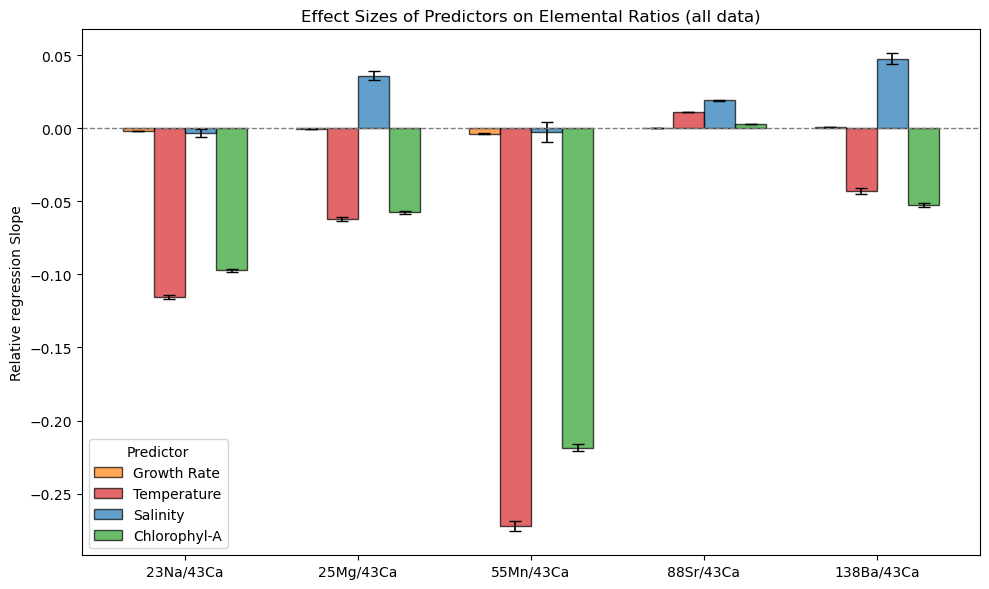

In [87]:
# Reshape the regression results to long format
effect_sizes_all = regression_results_all.melt(
    id_vars='Element',
    value_vars=['GR_slope_norm', 'T_slope_norm', 'S_slope_norm', 'Chl_slope_norm'],
    var_name='Predictor',
    value_name='EffectSize'
)

# Reshape regression slope standard errors to long format
effect_sizes_all_se = regression_results_all.melt(
    id_vars='Element',
    value_vars=['GR_slope_norm_se', 'T_slope_norm_se', 'S_slope_norm_se', 'Chl_slope_norm_se'],
    var_name='Predictor',
    value_name='SE'
)

# Ensure the predictors align for mapping and merging
predictor_map = {
    'GR_slope_norm': 'Growth Rate',
    'T_slope_norm': 'Temperature',
    'S_slope_norm': 'Salinity',
    'Chl_slope_norm': 'Chlorophyl-A',
    'GR_slope_norm_se': 'Growth Rate',
    'T_slope_norm_se': 'Temperature',
    'S_slope_norm_se': 'Salinity',
    'Chl_slope_norm_se': 'Chlorophyl-A'
}
effect_sizes_all['Predictor'] = effect_sizes_all['Predictor'].map(predictor_map)
effect_sizes_all_se['Predictor'] = effect_sizes_all_se['Predictor'].map(predictor_map)

# Merge effect sizes and standard errors
plot_data = pd.merge(effect_sizes_all, effect_sizes_all_se, on=['Element', 'Predictor'])

# Plot with error bars
elements = plot_data['Element'].unique()
predictors = plot_data['Predictor'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width = 0.18

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    # Subset data for this predictor
    df_sub = plot_data[plot_data['Predictor'] == predictor]

    # Align bar positions: offset each predictor
    positions = x + i * width
    
    # Use the color for this predictor
    color = predictor_colors.get(predictor, 'gray')  # fallback to gray if not found

    # Draw bars
    ax.bar(
        positions,
        df_sub['EffectSize'],
        width=width,
        label=predictor,
        yerr=df_sub['SE'],
        capsize=4,
        error_kw=dict(linewidth=1.2),
        color=color,
        alpha=0.7,
        edgecolor='black'
    )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(elements)

# Labels and title
ax.set_ylabel('Relative regression Slope')
ax.set_title('Effect Sizes of Predictors on Elemental Ratios (all data)')
ax.legend(title='Predictor')

plt.tight_layout()
plt.show()

## LASSO (Least Absolute Shrinkage and Selection Operator) regression

### Performs variable selection and shrinks coefficients
Here applied on summarized data

In [88]:
# Define predictors and responses
predictors = ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
responses = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']

# Store results
lasso_results = {}

# Standardize predictors once
X = data_summary[predictors].values
X_scaled = StandardScaler().fit_transform(X)

# Loop over each response variable
for response in responses:
    y = data_summary[response].values

    # Standardize response
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Drop rows with NaNs in either X or y
    valid_idx = ~np.isnan(X_scaled).any(axis=1) & ~np.isnan(y_scaled)
    X_valid = X_scaled[valid_idx]
    y_valid = y_scaled[valid_idx]

    if len(y_valid) < 5:
        print(f"Skipping {response} due to too few valid data points.")
        continue

    # Fit LASSO with cross-validation
    lasso = LassoCV(cv=5, random_state=0) # CV = 5 means 5-fold cross validation for parameter selection
    lasso.fit(X_valid, y_valid)

    # Save the coefficients
    coefs = pd.Series(lasso.coef_, index=predictors)

    # --- Post-LASSO uncertainty estimation---
    # Keep only non-zero coefficients
    selected = coefs[coefs != 0]

    if len(selected) == 0:
        lasso_results[response] = {
            'selected_predictors': [],
            'coefficients': [],
            'standard_errors': [],
            'alpha': lasso.alpha_
        }
        continue

    # Post-LASSO: OLS on selected predictors
    selected_predictors = selected.index.tolist()
    X_postlasso = X_valid[:, [predictors.index(p) for p in selected_predictors]]
    X_postlasso_const = sm.add_constant(X_postlasso)
    ols_model = sm.OLS(y_valid, X_postlasso_const).fit()

    # Extract standard errors (excluding constant)
    se = ols_model.bse[1:]  # skip intercept

    # Store results
    lasso_results[response] = {
        'selected_predictors': selected_predictors,
        'coefficients': selected.values.tolist(),
        'standard_errors': se.tolist(),
        'alpha': lasso.alpha_
    }

# Display results
for response, res in lasso_results.items():
    print(f"\nResponse: {response}")
    if res['selected_predictors']:
        print(f"  Selected predictors: {res['selected_predictors']}")
        print(f"  Coefficients:        {res['coefficients']}")
        print(f"  Std. Errors (post-OLS): {res['standard_errors']}")
        print(f"  Best alpha (lambda): {res['alpha']:.4f}")
    else:
        print("  No predictors selected.")


Response: NaCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.64045213431753, -0.12674466386967584, -0.06819228805014217, -0.7564971570007368]
  Std. Errors (post-OLS): [0.18888667295100825, 0.1919929172941908, 0.11726249223957065, 0.13456786176215788]
  Best alpha (lambda): 0.0352

Response: MgCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.31365921374969447, -0.048847475578841705, -0.015619671691000609, -0.3717943731109825]
  Std. Errors (post-OLS): [0.08518412076316642, 0.08658497498498967, 0.05288304433482337, 0.06068742070628733]
  Best alpha (lambda): 0.0002

Response: MnCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.27433110274532646, -0.05368263004621682, -0.02336906398670026, -0.32550113506921363]
  Std. Errors (post-OLS): [0.0831605426463968, 0.08452811909388054, 0.05162678940954652, 0.05924577013333764]


### Visualize results of LASSO regression

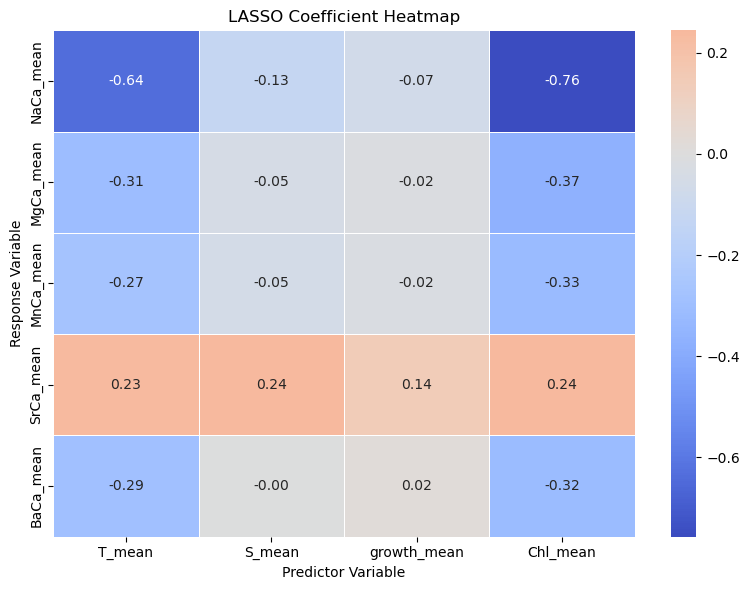

In [89]:
# Prepare coefficient matrix
# List of predictors and responses
predictors = ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
responses = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']

# Initialize coefficient matrix (rows = responses, columns = predictors)
coef_matrix = pd.DataFrame(0.0, index=responses, columns=predictors)

# Fill with non-zero coefficients
for response, result in lasso_results.items():
    for pred, coef in zip(result['selected_predictors'], result['coefficients']):
        coef_matrix.loc[response, pred] = coef

# Plot heatmap of coefficients
plt.figure(figsize=(8, 6))
sns.heatmap(coef_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt=".2f")
plt.title("LASSO Coefficient Heatmap")
plt.ylabel("Response Variable")
plt.xlabel("Predictor Variable")
plt.tight_layout()
plt.show()

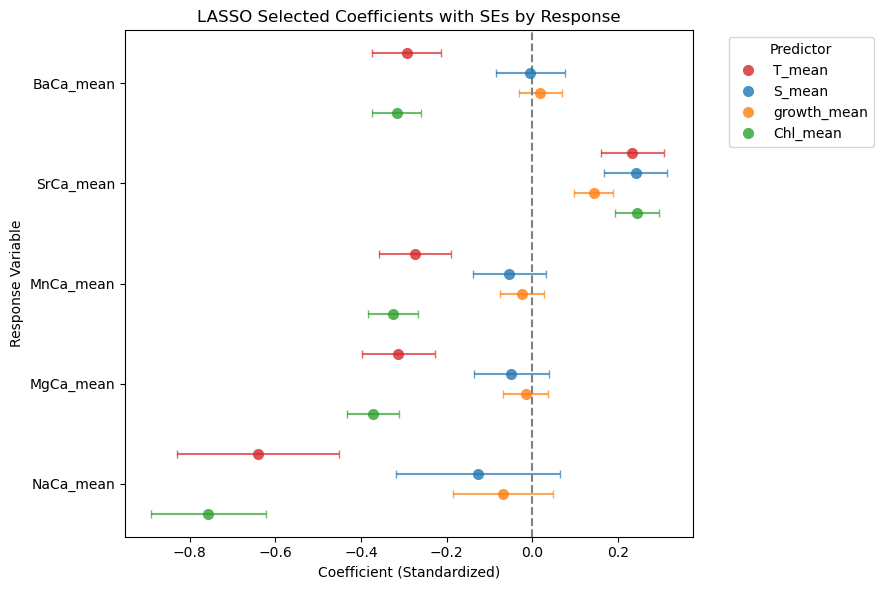

In [ ]:
# Map the hue levels to the colors (make keys match your df_effects 'Predictor' hue values)
stripplot_palette = {
    'T_mean': predictor_colors['Temperature'],
    'S_mean': predictor_colors['Salinity'],
    'growth_mean': predictor_colors['Growth Rate'],
    'Chl_mean': predictor_colors['Chlorophyl-A'],
}

# Effect size plot
# Build long-format dataframe with coefficients and SEs
effect_data = []
for response, res in lasso_results.items():
    for pred, coef, se in zip(res['selected_predictors'], res['coefficients'], res['standard_errors']):
        effect_data.append({
            'Response': response,
            'Predictor': pred,
            'Coefficient': coef,
            'SE': se
        })

df_effects = pd.DataFrame(effect_data)

# Sort responses for better plot layout (optional)
df_effects['Response'] = pd.Categorical(df_effects['Response'], categories=responses[::-1], ordered=True)

# Plot
plt.figure(figsize=(9, 6))
sns.stripplot(
    data=df_effects,
    x='Coefficient',
    y='Response',
    hue='Predictor',
    dodge=True,
    size=8,
    palette=stripplot_palette,
    alpha=0.8,
    # use predictor colors
    hue_order=['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
)

# Add error bars manually
for i, row in df_effects.iterrows():
    y = df_effects['Response'].cat.categories.tolist().index(row['Response'])  # vertical position
    hue_offset = 0.2 * (['T_mean', 'S_mean', 'growth_mean', 'Chl_mean'].index(row['Predictor']) - 1.5)
    predictor = row['Predictor']  # e.g., 'T_mean', etc.
    color = stripplot_palette.get(predictor, 'gray')  # fallback color
    plt.errorbar(
        x=row['Coefficient'],
        y=y + hue_offset,
        xerr=row['SE'],
        fmt='none',
        ecolor=color,
        elinewidth=1.5,
        capsize=3,
        alpha=0.7
    )

plt.axvline(0, color='gray', linestyle='--')
plt.title("LASSO Selected Coefficients with SEs by Response")
plt.xlabel("Coefficient (Standardized)")
plt.ylabel("Response Variable")
plt.legend(title='Predictor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Performs variable selection and shrinks coefficients
Here applied on all data

In [98]:
# Define predictors and responses
responses = ['23Na/43Ca', '25Mg/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
predictors = ['interval_growth_rate_centered', 'T', 'S', 'Chl']

# Store results
lasso_results_all = {}

# Standardize predictors once
X = all_data[predictors].values
X_scaled = StandardScaler().fit_transform(X)

# Loop over each response variable
for response in responses:
    y = all_data[response].values

    # Standardize response
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Drop rows with NaNs in either X or y
    valid_idx = ~np.isnan(X_scaled).any(axis=1) & ~np.isnan(y_scaled)
    X_valid = X_scaled[valid_idx]
    y_valid = y_scaled[valid_idx]

    if len(y_valid) < 5:
        print(f"Skipping {response} due to too few valid data points.")
        continue

    # Fit LASSO with cross-validation
    lasso = LassoCV(cv=5, random_state=0) # CV = 5 means 5-fold cross validation for parameter selection
    lasso.fit(X_valid, y_valid)

    # Save the coefficients
    coefs = pd.Series(lasso.coef_, index=predictors)

    # --- Post-LASSO uncertainty estimation---
    # Keep only non-zero coefficients
    selected = coefs[coefs != 0]

    if len(selected) == 0:
        lasso_results_all[response] = {
            'selected_predictors': [],
            'coefficients': [],
            'standard_errors': [],
            'alpha': lasso.alpha_
        }
        continue

    # Post-LASSO: OLS on selected predictors
    selected_predictors = selected.index.tolist()
    X_postlasso = X_valid[:, [predictors.index(p) for p in selected_predictors]]
    X_postlasso_const = sm.add_constant(X_postlasso)
    ols_model = sm.OLS(y_valid, X_postlasso_const).fit()

    # Extract standard errors (excluding constant)
    se = ols_model.bse[1:]  # skip intercept

    # Store results
    lasso_results_all[response] = {
        'selected_predictors': selected_predictors,
        'coefficients': selected.values.tolist(),
        'standard_errors': se.tolist(),
        'alpha': lasso.alpha_
    }

# Display the results
for response, res in lasso_results_all.items():
    print(f"\nResponse: {response}")
    if res['selected_predictors']:
        print(f"  Selected predictors: {res['selected_predictors']}")
        print(f"  Coefficients:        {res['coefficients']}")
        print(f"  Std. Errors (post-OLS): {res['standard_errors']}")
        print(f"  Best alpha (lambda): {res['alpha']:.4f}")
    else:
        print("  No predictors selected.")


Response: 23Na/43Ca
  Selected predictors: ['interval_growth_rate_centered', 'T', 'Chl']
  Coefficients:        [-0.05174258621549827, -0.16326306876630037, -0.14366831840911465]
  Std. Errors (post-OLS): [0.001788176037267854, 0.001954103902998354, 0.0016413206241646257]
  Best alpha (lambda): 0.0126

Response: 25Mg/43Ca
  Selected predictors: ['interval_growth_rate_centered', 'T', 'S', 'Chl']
  Coefficients:        [-0.006325524077653156, -0.026083573634500236, 0.0067173403168551615, -0.026591047503203038]
  Std. Errors (post-OLS): [0.0005560097710682298, 0.0006907197066871324, 0.0005758600935880949, 0.0005129920740262326]
  Best alpha (lambda): 0.0000

Response: 55Mn/43Ca
  Selected predictors: ['interval_growth_rate_centered', 'T', 'Chl']
  Coefficients:        [-0.004134251309715222, -0.014243746197578146, -0.011699712589571061]
  Std. Errors (post-OLS): [0.00017199296809772212, 0.0001879524852382788, 0.00015786790554547304]
  Best alpha (lambda): 0.0014

Response: 88Sr/43Ca
  Se

### Visualize results of LASSO regression

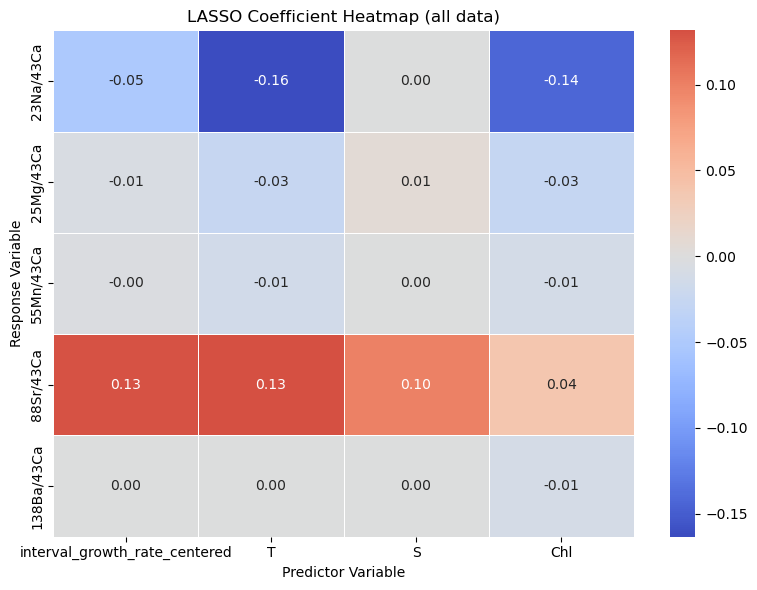

In [99]:
# Prepare coefficient matrix
# List of predictors and responses
responses = ['23Na/43Ca', '25Mg/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
predictors = ['interval_growth_rate_centered', 'T', 'S', 'Chl']

# Initialize coefficient matrix (rows = responses, columns = predictors)
coef_matrix_all = pd.DataFrame(0.0, index=responses, columns=predictors)

# Fill with non-zero coefficients
for response, result in lasso_results_all.items():
    for pred, coef in zip(result['selected_predictors'], result['coefficients']):
        coef_matrix_all.loc[response, pred] = coef

# Plot heatmap of coefficients
plt.figure(figsize=(8, 6))
sns.heatmap(coef_matrix_all, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt=".2f")
plt.title("LASSO Coefficient Heatmap (all data)")
plt.ylabel("Response Variable")
plt.xlabel("Predictor Variable")
plt.tight_layout()
plt.show()

ValueError: 'interval_growth_rate_centered' is not in list

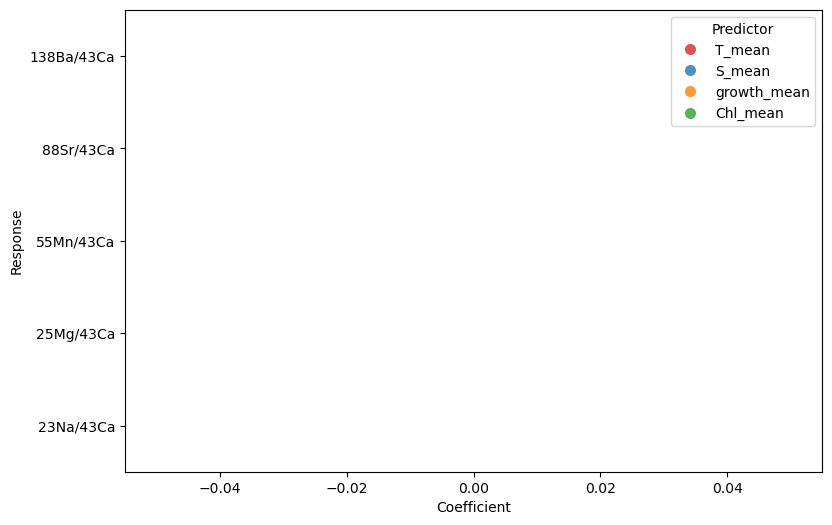

In [101]:
# Effect size plot
# Build long-format dataframe with coefficients and SEs
effect_data = []
for response, res in lasso_results_all.items():
    for pred, coef, se in zip(res['selected_predictors'], res['coefficients'], res['standard_errors']):
        effect_data.append({
            'Response': response,
            'Predictor': pred,
            'Coefficient': coef,
            'SE': se
        })

df_effects = pd.DataFrame(effect_data)

# Sort responses for better plot layout (optional)
df_effects['Response'] = pd.Categorical(df_effects['Response'], categories=responses[::-1], ordered=True)

# Plot
plt.figure(figsize=(9, 6))
sns.stripplot(
    data=df_effects,
    x='Coefficient',
    y='Response',
    hue='Predictor',
    dodge=True,
    size=8,
    palette=stripplot_palette,
    alpha=0.8,
    # use predictor colors
    hue_order=['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
)

# Add error bars manually
for i, row in df_effects.iterrows():
    y = df_effects['Response'].cat.categories.tolist().index(row['Response'])  # vertical position
    hue_offset = 0.2 * (['T_mean', 'S_mean', 'growth_mean', 'Chl_mean'].index(row['Predictor']) - 1.5)
    predictor = row['Predictor']  # e.g., 'T_mean', etc.
    color = stripplot_palette.get(predictor, 'gray')  # fallback color
    plt.errorbar(
        x=row['Coefficient'],
        y=y + hue_offset,
        xerr=row['SE'],
        fmt='none',
        ecolor=color,
        elinewidth=1.5,
        capsize=3,
        alpha=0.7
    )

plt.axvline(0, color='gray', linestyle='--')
plt.title("LASSO Selected Coefficients with SEs by Response")
plt.xlabel("Coefficient (Standardized)")
plt.ylabel("Response Variable")
plt.legend(title='Predictor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




# # Effect size plot
# # Flatten the matrix for plotting
# coef_long_all = coef_matrix_all.reset_index().melt(id_vars='index', var_name='Predictor', value_name='Coefficient')
# coef_long_all = coef_long_all.rename(columns={'index': 'Response'})

# # Keep only non-zero effects
# coef_long_all = coef_long_all[coef_long_all['Coefficient'] != 0]

# plt.figure(figsize=(8, 6))
# sns.stripplot(data=coef_long_all, x='Coefficient', y='Response', hue='Predictor', dodge=True, size=8, palette='Set2')
# plt.axvline(0, color='gray', linestyle='--')
# plt.title("LASSO Selected Coefficients by Response (all data)")
# plt.xlabel("Coefficient (Standardized)")
# plt.ylabel("Response Variable")
# plt.legend(title='Predictor', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

### Repeat LASSO regression on subtidal and intertidal datasets

## Variance decomposition using stepwise linear modelling (large - small effect)

### Stepwise York regression + R-squared for variance decomposition

## Errors of reverse prediction

### Switch dependent and independent variables to calculate possible prediction of environmental variables